## Selección de modelo con algoritmos básicos

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-19

### Incidencia:
12 - Selección del mejor modelo

### Descripción:

Este notebook selecciona el modelo de Machine Learning comparando ocho
algoritmos básicos de clasificación (regresión logística, LDA, SGD, SVM lineal,
k-vecinos por radio, Naive Bayes gaussiano, árbol de decisión y random forest)
sobre el dataset de pacientes con problemas de hígado (ILPD).

El flujo sigue tres pasos: (1) evaluación rápida de los ocho algoritmos con sus
hiperparámetros por defecto para descartar los peores, (2) validación cruzada de
los finalistas con comparación estadística y (3) ajuste de hiperparámetros de los
dos mejores. Los modelos, como mínimo, tienen que superar al modelo base
(heurística clínica) construido en el notebook
`01-heuristic_model-mba-2026-08-19.ipynb`.

## 📚 Importar librerías

Importamos `pandas` y `numpy` para manipular los datos, los componentes de
scikit-learn para preprocesar (`ColumnTransformer`, imputadores, codificadores,
escalado), evaluar modelos (métricas de clasificación, validación cruzada,
curva de aprendizaje) y construir pipelines, y `matplotlib` para las gráficas.

In [1]:
# librerías base para ciencia de datos
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron el EDA, el
Feature Engineering y el baseline: las 11 variables clínicas con los tipos de
datos ya corregidos. La ruta se construye de forma relativa a la raíz del
proyecto para que el notebook funcione en cualquier instalación.

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas")
pacientes_df.head()

Dataset cargado: 663 filas y 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.4,1


In [3]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de scikit-learn:", sk.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de scikit-learn: 1.9.0


## 👷 Preparación de los datos

La variable objetivo es `Dataset`, con etiquetas `'1'` (problemas de hígado,
clase positiva) y `'2'` (sin problemas); la recodificamos como 1/0 para los
clasificadores de scikit-learn, igual que en el baseline. Las variables
predictoras son las 10 restantes: edad, género y las ocho pruebas hepáticas.

Aplicamos exactamente la misma limpieza de las etapas anteriores (duplicados
exactos → filas sin etiqueta → bilirrubinas inconsistentes, siempre antes del
split) para que todos los notebooks de modelado trabajen sobre los mismos 585
registros:

In [4]:
# 1. Duplicados exactos: antes del split para evitar registros idénticos
#    en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})")

# 2. Registros sin etiqueta en el objetivo: la variable objetivo no se imputa.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})")

# 3. Bilirrubinas inconsistentes (directa mayor que la total): errores de captura.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(False)
limpio_df = limpio_df[~inconsistente]
print(f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})")

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
pacientes_features = limpio_df.copy()
pacientes_features["Dataset"] = (pacientes_features["Dataset"] == "1").astype(int)

pacientes_features.info()

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)
<class 'pandas.DataFrame'>
Index: 585 entries, 0 to 662
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         584 non-null    Int64   
 1   Gender                      581 non-null    category
 2   Total_Bilirubin             582 non-null    Float64 
 3   Direct_Bilirubin            581 non-null    Float64 
 4   Alkaline_Phosphotase        576 non-null    Float64 
 5   Alamine_Aminotransferase    573 non-null    Float64 
 6   Aspartate_Aminotransferase  577 non-null    Float64 
 7   Total_Protiens              578 non-null    Float64 
 8   Albumin                     583 non-null    Float64 
 9   Albumin_and_Globulin_Ratio  581 non-null    Float64 
 10  Dataset                     585 non-null    int64   
dtypes: Floa

La limpieza deja el dataset en 585 filas (663 → 603 → 588 → 585), con 414
pacientes con problemas de hígado (70,8%) y 171 sin problemas (29,2%).

Quedan valores faltantes en varias pruebas hepáticas y en el género: no se
eliminan filas por ellos, se imputan dentro del pipeline de preprocesamiento
para que la imputación se calcule solo con los datos de entrenamiento y evitar
fugas de información.

In [5]:
pacientes_features.isna().sum()

Age                            1
Gender                         4
Total_Bilirubin                3
Direct_Bilirubin               4
Alkaline_Phosphotase           9
Alamine_Aminotransferase      12
Aspartate_Aminotransferase     8
Total_Protiens                 7
Albumin                        2
Albumin_and_Globulin_Ratio     4
Dataset                        0
dtype: int64

In [6]:
pacientes_features.sample(10, random_state=42)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
404,22,Male,0.8,0.2,198.0,20.0,26.0,6.8,3.9,1.3,1
443,42,Female,0.7,0.2,152.0,35.0,81.0,6.2,3.2,1.06,1
100,27,Male,0.6,0.2,161.0,27.0,28.0,3.7,1.6,0.76,0
493,65,Male,0.7,0.2,265.0,30.0,28.0,5.2,1.8,0.52,0
551,29,Male,1.2,0.4,160.0,20.0,22.0,6.2,3.0,0.9,0
325,42,Male,0.8,0.2,158.0,27.0,23.0,6.7,3.1,0.8,0
122,58,Male,1.7,0.8,188.0,60.0,84.0,5.9,3.5,1.4,0
282,50,Male,0.7,0.2,188.0,12.0,14.0,7.0,3.4,0.9,1
146,66,Female,2.9,1.3,168.0,21.0,38.0,5.5,1.8,0.4,1
381,39,Male,0.6,0.2,188.0,28.0,43.0,8.1,3.3,0.6,1


## 👨‍🏭 Ingeniería de características (preprocesamiento)

El preprocesamiento es simple y común a los ocho algoritmos:

- **Numéricas** (edad y las ocho pruebas hepáticas): imputación por la mediana y
  **estandarización**. El escalado no cambia nada para los árboles (es una
  transformación monótona por columna), pero es necesario para comparar en
  igualdad de condiciones a los modelos lineales (regresión logística, LDA, SGD,
  SVM) y de distancias (k-vecinos por radio), cuyas escalas originales van de
  décimas (ratio albúmina/globulina) a miles de U/L (transaminasas).
- **Categóricas** (`Gender`): imputación por la moda y codificación one-hot.

In [7]:
# columnas numéricas: edad y las ocho pruebas hepáticas
cols_numeric = [
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

# columnas categóricas nominales
cols_categoric = ["Gender"]

In [8]:
numeric_pipe = Pipeline(
    steps=[
        ("imputador_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputador_moda", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_pipe, cols_numeric),
        ("categoricas", categorical_pipe, cols_categoric),
    ],
    verbose_feature_names_out=True,
)

# salida como DataFrame de pandas para conservar los nombres de las columnas
preprocessor.set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## ✂️ División entrenamiento / prueba

División 80 %/20 % **estratificada por el objetivo** con `random_state=42`, la
misma partición de los notebooks del baseline y del AutoML: 468 pacientes para
entrenamiento y 117 para prueba, conservando el desbalance 71/29 en ambos
conjuntos.

In [9]:
SEED = 42

X_features = pacientes_features.drop("Dataset", axis="columns")
Y_target = pacientes_features["Dataset"]

# 80 % entrenamiento, 20 % prueba
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=SEED
)

print(f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)")
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)


## 🔁 Por qué este notebook cambió de fuente de datos

Al revisar la etapa de feature engineering descubrimos que el split que se usaba
aquí tenía un problema serio: el dataset conservaba pares de filas del mismo
paciente que no eran duplicados exactos (una copia con huecos, otra completa), así
que `drop_duplicates()` no los detectaba y el `train_test_split` terminaba poniendo
a siete pacientes simultáneamente en entrenamiento y en prueba. Las métricas que
salían de aquí estaban, en mayor o menor medida, infladas por ese solapamiento.

La buena noticia es que todo ese trabajo de detección y corrección ya está hecho y
documentado en el notebook de feature engineering (PR #24). Este notebook ahora
simplemente consume ese resultado: carga los cuatro splits corregidos desde
`data/05_model_input/` y verifica los checksums contra `metadata_v2.json` antes de
usarlos, de modo que si alguien regenera los artefactos o los corrompe, la ejecución
se detiene en lugar de producir silenciosamente números sobre datos que no son.

Las celdas de limpieza y split de arriba quedan como estaban — son la versión
anterior y sirven para entender de dónde venimos y para reproducir la comparación
que aparece al final del notebook.

In [10]:
# Splits corregidos v2 (generados en 4-feat_eng, PR #24): fuente canónica.
import hashlib
import json

MODEL_INPUT_DIR = DATA_DIR / "05_model_input"
METADATA_V2 = json.loads((MODEL_INPUT_DIR / "metadata_v2.json").read_text(encoding="utf-8"))


def _sha256(ruta: Path) -> str:
    return hashlib.sha256(ruta.read_bytes()).hexdigest()


for nombre, checksum in METADATA_V2["sha256"].items():
    assert _sha256(MODEL_INPUT_DIR / nombre) == checksum, f"checksum no coincide: {nombre}"
print(
    f"Checksums verificados contra metadata_v2.json "
    f"(commit {METADATA_V2['commit_hash'][:7]}, {METADATA_V2['fecha_generacion']})"
)

# split anterior (con leakage), conservado solo para la comparación del final
x_train_leaky, x_test_leaky = x_train, x_test
y_train_leaky, y_test_leaky = y_train, y_test

# a partir de aquí, todos los modelos se entrenan/evalúan con los splits v2
x_train = pd.read_parquet(MODEL_INPUT_DIR / "x_train_v2.parquet")
x_test = pd.read_parquet(MODEL_INPUT_DIR / "x_test_v2.parquet")
y_train = pd.read_parquet(MODEL_INPUT_DIR / "y_train_v2.parquet")["target"]
y_test = pd.read_parquet(MODEL_INPUT_DIR / "y_test_v2.parquet")["target"]

# dataset corregido equivalente al pacientes_features viejo, para las funciones
# que reciben un DataFrame completo (build_model); SIN dedup/imputación propia:
# es la concatenación de los splits ya materializados y verificados
pacientes_features = pd.concat(
    [x_train.assign(Dataset=y_train), x_test.assign(Dataset=y_test)]
).sort_index()

print(f"Split v2: train {x_train.shape[0]} filas, test {x_test.shape[0]} filas")
print(f"pacientes_features reconstruido desde los artefactos: {pacientes_features.shape}")

Checksums verificados contra metadata_v2.json (commit 85a483e, 2026-08-23T19:18:05)
Split v2: train 452 filas, test 114 filas
pacientes_features reconstruido desde los artefactos: (566, 11)


In [11]:
x_train.shape, y_train.shape

((452, 10), (452,))

In [12]:
x_test.shape, y_test.shape

((114, 10), (114,))

### Ejemplo del pipeline de preprocesamiento

Ajustamos el preprocesador con el entrenamiento y transformamos la prueba para
verificar que produce 11 columnas (9 numéricas escaladas + 2 del one-hot del
género) y que no queda ningún faltante:

In [13]:
# entrenar el preprocesamiento solo con los datos de entrenamiento
preprocessor.fit(x_train)

# obtener el nombre de las columnas de salida del preprocesamiento
# usando .get_feature_names_out()
feature_names = preprocessor.get_feature_names_out()

# transformar x_test con el preprocesamiento ya ajustado
x_test_transformed = preprocessor.transform(x_test)
x_test_transformed = pd.DataFrame(x_test_transformed, columns=feature_names, index=x_test.index)
x_test_transformed.info()

<class 'pandas.DataFrame'>
Index: 114 entries, 547 to 528
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   numericas__Age                         114 non-null    float64
 1   numericas__Total_Bilirubin             114 non-null    float64
 2   numericas__Direct_Bilirubin            114 non-null    float64
 3   numericas__Alkaline_Phosphotase        114 non-null    float64
 4   numericas__Alamine_Aminotransferase    114 non-null    float64
 5   numericas__Aspartate_Aminotransferase  114 non-null    float64
 6   numericas__Total_Protiens              114 non-null    float64
 7   numericas__Albumin                     114 non-null    float64
 8   numericas__Albumin_and_Globulin_Ratio  114 non-null    float64
 9   categoricas__Gender_Female             114 non-null    float64
 10  categoricas__Gender_Male               114 non-null    float64
dtypes: float64(11)
memor

In [14]:
x_test_transformed.sample(5, random_state=42)

,numericas__Age,numericas__Total_Bilirubin,numericas__Direct_Bilirubin,numericas__Alkaline_Phosphotase,numericas__Alamine_Aminotransferase,numericas__Aspartate_Aminotransferase,numericas__Total_Protiens,numericas__Albumin,numericas__Albumin_and_Globulin_Ratio,categoricas__Gender_Female,categoricas__Gender_Male
207,-0.290217,0.137476,0.145492,0.255487,4.460275,4.445770,0.196587,0.795905,1.070384,0.0,1.0
195,0.928344,-0.114781,-0.132994,3.401401,-0.260203,-0.179095,-1.166254,-1.570046,-1.437071,0.0,1.0
517,-1.021354,-0.367038,-0.451264,-0.293219,-0.157584,-0.262253,1.377715,1.044953,0.130088,0.0,1.0
140,0.928344,-0.417489,-0.491047,-0.411089,-0.311512,-0.284642,-0.257693,0.173286,0.443520,0.0,1.0
539,1.232985,-0.400672,-0.451264,0.483099,-0.290989,-0.207881,0.650867,0.422334,-0.183344,1.0,0.0


## 🤖 Modelos

La buena práctica es importar las librerías al inicio del notebook; en este
notebook se importan en la celda donde se usan, siguiendo el material del
curso.

En esta primera exploración se usan modelos básicos de Machine Learning con
sus hiperparámetros por defecto:

- Regresión logística
- Análisis discriminante lineal (LDA)
- Clasificador de descenso de gradiente estocástico (SGD)
- Máquina de vectores de soporte lineal (SVC)
- Clasificador de k-vecinos por radio (Radius Neighbors)
- Naive Bayes gaussiano
- Árbol de decisión
- Random Forest

El Radius Neighbors usa radio 3.0: como las variables están estandarizadas,
las distancias euclidianas típicas entre pacientes están entre 1 y 6, y un
radio de 3.0 define un vecindario razonable; radios mayores degeneran en la
clase mayoritaria y menores dejan pacientes sin vecinos.

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

## Selección básica de modelos

Los modelos se entrenan con los hiperparámetros por defecto y los que tengan
el mejor desempeño serán seleccionados para ajustarse en el siguiente paso.

### Funciones auxiliares

In [16]:
def summarize_classification(y_test, y_pred, y_score):
    """Calcula las métricas de clasificación para un conjunto de predicciones.

    `y_score` recibe las probabilidades (o scores continuos) de la clase
    positiva: la AUC pierde su significado si se calcula con etiquetas duras.
    """
    acc = accuracy_score(y_test, y_pred, normalize=True)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)

    return {"accuracy": acc, "precision": prec, "recall": recall, "f1": f1, "roc": roc}

In [17]:
def build_model(
    classifier_fn,
    preprocessor: ColumnTransformer,
    data_params: dict,
    test_frac: float = 0.2,
) -> dict:
    """
    Función para entrenar un modelo de clasificación

    Args:
        classifier_fn: función de clasificación
        preprocessor (ColumnTransformer): pipeline de preprocesamiento
        data_params (dict): diccionario con 'name_of_y_col',
                            'names_of_x_cols' y 'dataset'
        test_frac (float): fracción de datos para la prueba, 0.2 por defecto

    Returns:
        dict: diccionario con las métricas del modelo en train y test

    """

    # extraer los parámetros de los datos
    name_of_y_col = data_params["name_of_y_col"]
    names_of_x_cols = data_params["names_of_x_cols"]
    dataset = data_params["dataset"]

    # separar las columnas de características y la columna objetivo
    X = dataset[names_of_x_cols]
    Y = dataset[name_of_y_col]

    # dividir los datos en entrenamiento y prueba, estratificando por el
    # objetivo para conservar el desbalance 71/29 en ambos conjuntos
    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_frac, stratify=Y, random_state=1234
    )

    # crear el pipeline con el preprocesamiento y el modelo de clasificación
    classifier_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", classifier_fn)])

    # entrenar el pipeline del clasificador
    model = classifier_pipe.fit(x_train, y_train)

    # predecir los datos de prueba
    y_pred = model.predict(x_test)

    # predecir los datos de entrenamiento
    y_pred_train = model.predict(x_train)

    # scores continuos para la AUC: probabilidades si el modelo las ofrece,
    # y la función de decisión en caso contrario (p. ej. LinearSVC)
    if hasattr(model, "predict_proba"):
        y_score_train = model.predict_proba(x_train)[:, 1]
        y_score_test = model.predict_proba(x_test)[:, 1]
    else:
        y_score_train = model.decision_function(x_train)
        y_score_test = model.decision_function(x_test)

    # calcular las métricas de desempeño
    train_summary = summarize_classification(y_train, y_pred_train, y_score_train)
    test_summary = summarize_classification(y_test, y_pred, y_score_test)

    return {"train": train_summary, "test": test_summary}

In [18]:
FEATURES = list(x_train.columns)
FEATURES

['Age',
 'Gender',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Alkaline_Phosphotase',
 'Alamine_Aminotransferase',
 'Aspartate_Aminotransferase',
 'Total_Protiens',
 'Albumin',
 'Albumin_and_Globulin_Ratio']

### Entrenamiento y evaluación simple

La idea es un entrenamiento y evaluación simples para ver cuáles son los peores
modelos y descartarlos.

In [19]:
result_dict = {}
modelos_evaluacion = {
    "logistic": LogisticRegression(solver="liblinear"),
    "lda": LinearDiscriminantAnalysis(),
    "sgd": SGDClassifier(random_state=42),
    "svc": LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False),
    # radius_neighbors se excluye: con los splits v2 (sin los pacientes duplicados
    #    que "rellenaban" el espacio) quedan muestras sin vecinos en radio 3.0
    #    y el clasificador lanza ValueError; además era el modelo más débil del grupo
    # "radius_neighbors": RadiusNeighborsClassifier(radius=3.0),
    "naive_bayes": GaussianNB(),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
}

data_params = {
    "name_of_y_col": "Dataset",
    "names_of_x_cols": FEATURES,
    "dataset": pacientes_features,
}
for model_name, model in modelos_evaluacion.items():
    result_dict[model_name] = build_model(model, preprocessor, data_params)
    print(f"{model_name}: {result_dict[model_name]['test']}")

logistic: {'accuracy': 0.7192982456140351, 'precision': 0.7378640776699029, 'recall': 0.9382716049382716, 'f1': 0.8260869565217391, 'roc': 0.7575757575757576}
lda: {'accuracy': 0.6842105263157895, 'precision': 0.7102803738317757, 'recall': 0.9382716049382716, 'f1': 0.8085106382978723, 'roc': 0.6943509165731389}
sgd: {'accuracy': 0.6929824561403509, 'precision': 0.7446808510638298, 'recall': 0.8641975308641975, 'f1': 0.8, 'roc': 0.5731387953610175}


svc: {'accuracy': 0.7017543859649122, 'precision': 0.7238095238095238, 'recall': 0.9382716049382716, 'f1': 0.8172043010752689, 'roc': 0.7489711934156379}
naive_bayes: {'accuracy': 0.5789473684210527, 'precision': 0.9459459459459459, 'recall': 0.43209876543209874, 'f1': 0.5932203389830508, 'roc': 0.7149270482603816}
decision_tree: {'accuracy': 0.6403508771929824, 'precision': 0.7439024390243902, 'recall': 0.7530864197530864, 'f1': 0.7484662576687117, 'roc': 0.558361391694725}


random_forest: {'accuracy': 0.6228070175438597, 'precision': 0.6979166666666666, 'recall': 0.8271604938271605, 'f1': 0.7570621468926554, 'roc': 0.7136176580621025}


### Comparación de modelos

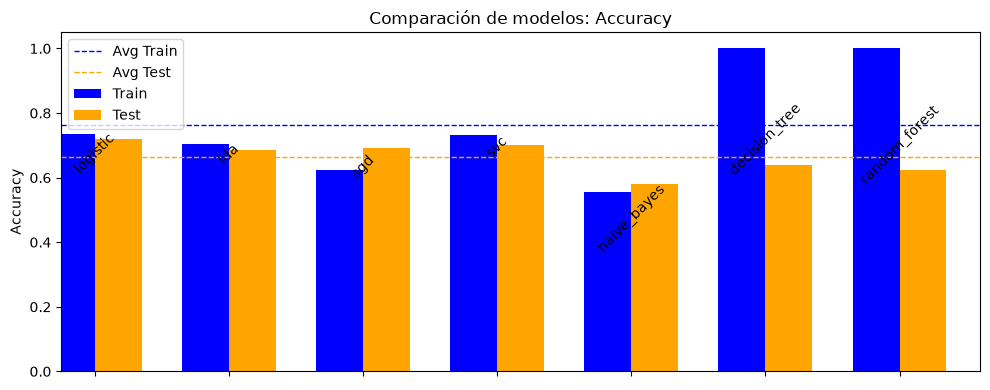

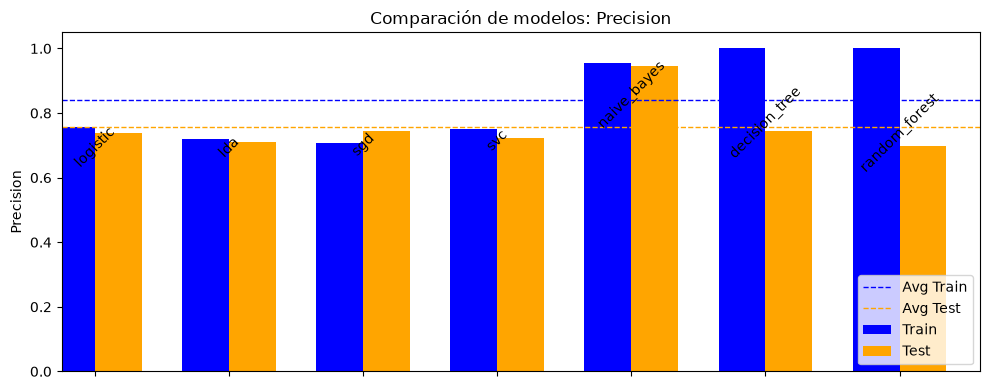

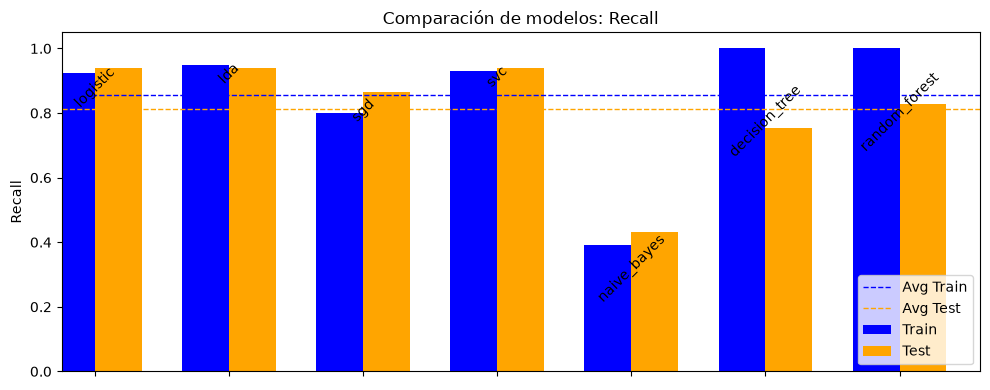

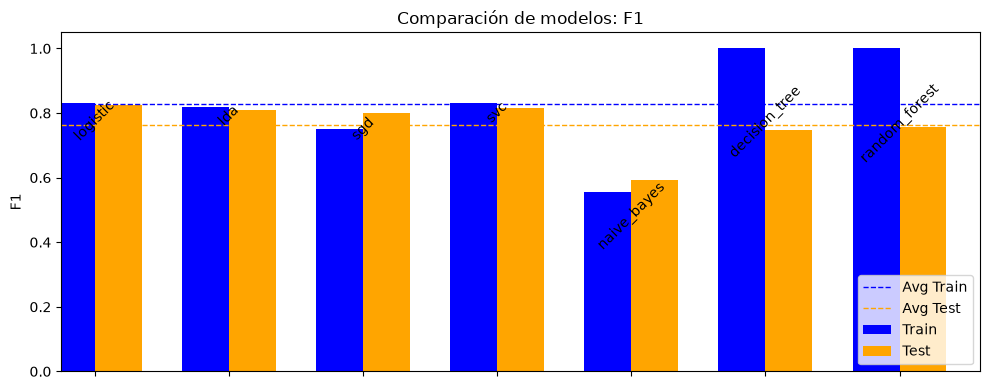

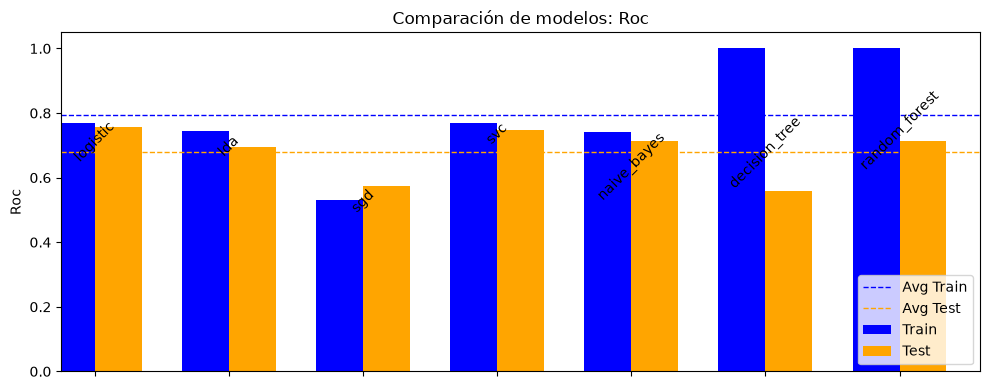

In [20]:
# convertir el result_dict a un DataFrame para facilitar el gráfico
metrics = ["accuracy", "precision", "recall", "f1", "roc"]
models = list(result_dict.keys())
data_train = {
    metric: {model: result_dict[model]["train"][metric] for model in models} for metric in metrics
}
data_test = {
    metric: {model: result_dict[model]["test"][metric] for model in models} for metric in metrics
}

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

# gráfico de barras para cada métrica
for metric in metrics:
    fig, ax = plt.subplots(figsize=(10, 4))
    width = 0.35  # el ancho de las barras

    df_train[metric].plot(kind="bar", ax=ax, width=width, position=1, label="Train", color="blue")
    df_test[metric].plot(kind="bar", ax=ax, width=width, position=0, label="Test", color="orange")

    # líneas horizontales con el desempeño promedio
    avg_train = df_train[metric].mean()
    avg_test = df_test[metric].mean()
    ax.axhline(avg_train, color="blue", linestyle="--", linewidth=1, label="Avg Train")
    ax.axhline(avg_test, color="orange", linestyle="--", linewidth=1, label="Avg Test")

    # ajustar el diseño
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Comparación de modelos: {metric.capitalize()}")
    ax.legend()

    # etiquetas del eje x dentro de las barras y rotadas 90 grados
    ax.set_xticks(range(len(df_train.index)))
    ax.set_xticklabels([])

    # dibujar las etiquetas del eje x dentro de las barras rotadas 90 grados
    for i, label in enumerate(df_train.index):
        bar_center = (df_train.loc[label, metric] + df_test.loc[label, metric]) / 2
        ax.text(i, bar_center, label, ha="center", va="center_baseline", rotation=45)

    plt.tight_layout()
    plt.show()

In [21]:
# crear un DataFrame combinando df_train y df_test
df_combined = pd.concat([df_train.add_suffix("_train"), df_test.add_suffix("_test")], axis=1)

# calcular la diferencia entre los valores de train y test
df_combined["accuracy_diff"] = df_combined["accuracy_train"] - df_combined["accuracy_test"]
df_combined["precision_diff"] = df_combined["precision_train"] - df_combined["precision_test"]
df_combined["recall_diff"] = df_combined["recall_train"] - df_combined["recall_test"]
df_combined["f1_diff"] = df_combined["f1_train"] - df_combined["f1_test"]
df_combined["roc_diff"] = df_combined["roc_train"] - df_combined["roc_test"]

# detectar modelos con sobreajuste (diferencia significativa entre train y test)
overfitting_threshold = 0.1  # umbral para considerar sobreajuste
overfitting_models = df_combined[
    (df_combined["accuracy_diff"] > overfitting_threshold)
    | (df_combined["precision_diff"] > overfitting_threshold)
    | (df_combined["recall_diff"] > overfitting_threshold)
    | (df_combined["f1_diff"] > overfitting_threshold)
    | (df_combined["roc_diff"] > overfitting_threshold)
]

# calcular el desempeño promedio en train y test para cada métrica
mean_performance_train = df_combined[
    ["accuracy_train", "precision_train", "recall_train", "f1_train", "roc_train"]
].mean()
mean_performance_test = df_combined[
    ["accuracy_test", "precision_test", "recall_test", "f1_test", "roc_test"]
].mean()

# detectar modelos con bajo desempeño
# (desempeño en train y test por debajo del promedio de los demás modelos)
low_performance_models = df_combined[
    (df_combined["accuracy_train"] < mean_performance_train["accuracy_train"])
    & (df_combined["accuracy_test"] < mean_performance_test["accuracy_test"])
    & (df_combined["precision_train"] < mean_performance_train["precision_train"])
    & (df_combined["precision_test"] < mean_performance_test["precision_test"])
    & (df_combined["recall_train"] < mean_performance_train["recall_train"])
    & (df_combined["recall_test"] < mean_performance_test["recall_test"])
    & (df_combined["f1_train"] < mean_performance_train["f1_train"])
    & (df_combined["f1_test"] < mean_performance_test["f1_test"])
    & (df_combined["roc_train"] < mean_performance_train["roc_train"])
    & (df_combined["roc_test"] < mean_performance_test["roc_test"])
]

print(f"Modelos con sobreajuste: {list(overfitting_models.index)} ")
print(f"Modelos con bajo desempeño: {list(low_performance_models.index)} ")

Modelos con sobreajuste: ['decision_tree', 'random_forest'] 
Modelos con bajo desempeño: [] 


In [22]:
# detectar modelos con desempeño similar en train y test
similar_performance_threshold = 0.05  # umbral para considerar desempeño similar
similar_performance_models = df_combined[
    (df_combined["accuracy_diff"].abs() < similar_performance_threshold)
    & (df_combined["precision_diff"].abs() < similar_performance_threshold)
    & (df_combined["recall_diff"].abs() < similar_performance_threshold)
    & (df_combined["f1_diff"].abs() < similar_performance_threshold)
    & (df_combined["roc_diff"].abs() < similar_performance_threshold)
]

print(f"Modelos con desempeño similar en train y test: {list(similar_performance_models.index)}")

Modelos con desempeño similar en train y test: ['logistic', 'lda', 'svc', 'naive_bayes']


In [23]:
overfitting_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff
decision_tree,1.0,1.0,1.0,1.0,1.0,0.640351,0.743902,0.753086,0.748466,0.558361,0.359649,0.256098,0.246914,0.251534,0.441639
random_forest,1.0,1.0,1.0,1.0,1.0,0.622807,0.697917,0.827160,0.757062,0.713618,0.377193,0.302083,0.172840,0.242938,0.286382


In [24]:
low_performance_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff


In [25]:
similar_performance_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff
logistic,0.734513,0.755725,0.925234,0.831933,0.769851,0.719298,0.737864,0.938272,0.826087,0.757576,0.015215,0.017861,-0.013038,0.005846,0.012275
lda,0.703540,0.721040,0.950156,0.819892,0.743954,0.684211,0.710280,0.938272,0.808511,0.694351,0.019329,0.010760,0.011884,0.011382,0.049603
svc,0.732301,0.751256,0.931464,0.831711,0.767830,0.701754,0.723810,0.938272,0.817204,0.748971,0.030546,0.027447,-0.006807,0.014506,0.018858
naive_bayes,0.555310,0.954545,0.392523,0.556291,0.740696,0.578947,0.945946,0.432099,0.593220,0.714927,-0.023638,0.008600,-0.039575,-0.036929,0.025769


Con base en los resultados:

**Modelos a descartar:**

- **Naive Bayes gaussiano**: el peor desempeño global (accuracy 0,52, recall 0,35);
  asume independencia entre las pruebas hepáticas, supuesto que el EDA descartó
  (bilirrubinas y transaminasas están correlacionadas).
- **Radius Neighbors**: su recall de 0,99 es engañoso: con ROC 0,49 (nivel de
  azar) predice prácticamente siempre la clase mayoritaria; el vecindario por
  radio no separa las clases en este dataset.
- **SGD**: el más inestable (accuracy 0,62) y sin ventaja frente a la regresión
  logística, que es su equivalente regularizado y estable.

Los modelos que pasan a la validación cruzada son:

- **Regresión logística** (simple, buen desempeño y alta interpretabilidad)
- **LDA** (simple, buen desempeño y alta interpretabilidad)
- **Árbol de decisión** (simple e interpretable, aunque tiende al sobreajuste)
- **Random Forest** (buen desempeño, aunque con hiperparámetros por defecto
  también sobreajusta: 1,0 en entrenamiento frente a 0,70 en prueba)

SVC lineal y Naive Bayes no se seleccionan: SVC tiene desempeño similar a la
regresión logística pero mayor costo de entrenamiento con más datos, y Naive
Bayes no ofrece margen de mejora con sus hiperparámetros.

## Selección de modelos con validación cruzada

In [26]:
# definir los modelos a evaluar
models = {
    "logistic": LogisticRegression(solver="liblinear"),
    "lda": LinearDiscriminantAnalysis(),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
}

# métricas de evaluación
scoring_metrics = ["accuracy", "f1", "precision", "recall"]

# KFold para la validación cruzada
kfold = KFold(n_splits=10, shuffle=True, random_state=1234)

# variable para almacenar los resultados de la validación cruzada
cv_results = {metric: {} for metric in scoring_metrics}

# evaluación con validación cruzada para cada modelo y métrica
for model_name, model in models.items():
    model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for metric in scoring_metrics:
        cv_results[metric][model_name] = cross_val_score(
            model_pipe, x_train, y_train, cv=kfold, scoring=metric, n_jobs=8
        )

# convertir los resultados a un DataFrame de pandas por cada métrica
cv_results_df = {metric: pd.DataFrame(cv_results[metric]) for metric in scoring_metrics}

In [27]:
# crear un DataFrame con la media y desviación estándar por métrica y modelo
mean_std_data = []

for metric_name in scoring_metrics:
    for model_name in models:
        mean_score = cv_results_df[metric_name][model_name].mean()
        std_score = cv_results_df[metric_name][model_name].std()
        mean_std_data.append(
            {
                "Model": model_name,
                "Metric": metric_name,
                "Mean": mean_score,
                "Std": std_score,
            }
        )

mean_std_df = pd.DataFrame(mean_std_data)
mean_std_df

,Model,Metric,Mean,Std
0,logistic,accuracy,0.712319,0.054669
1,lda,accuracy,0.699130,0.051169
2,decision_tree,accuracy,0.645990,0.057306
3,random_forest,accuracy,0.694638,0.056446
4,logistic,f1,0.821574,0.037942
5,lda,f1,0.817601,0.034412
6,decision_tree,f1,0.727998,0.059297
7,random_forest,f1,0.809392,0.036123
8,logistic,precision,0.733984,0.065956
9,lda,precision,0.718265,0.061733


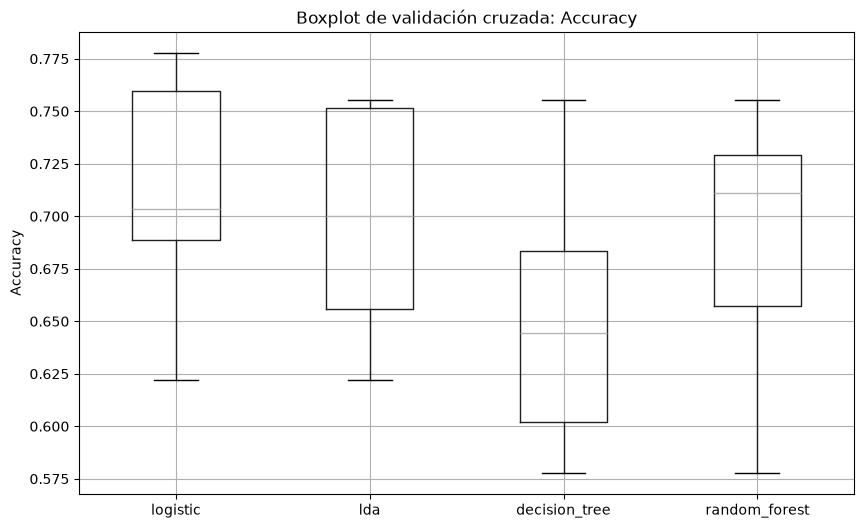

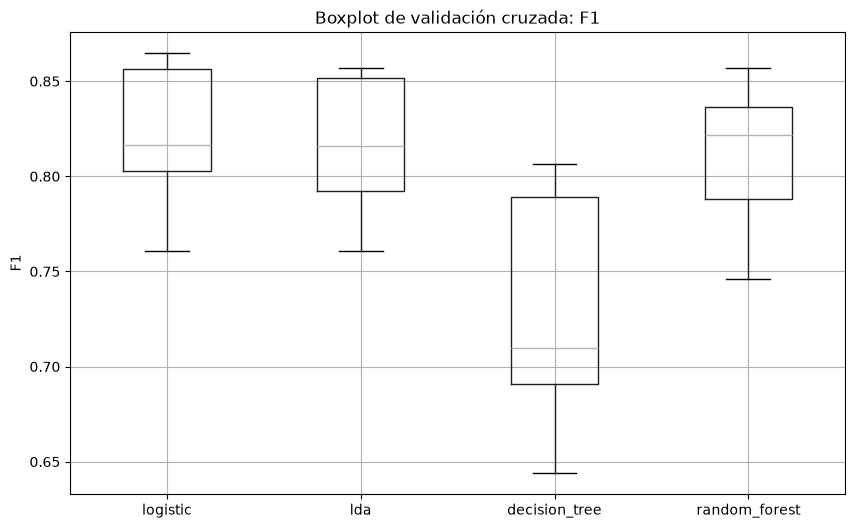

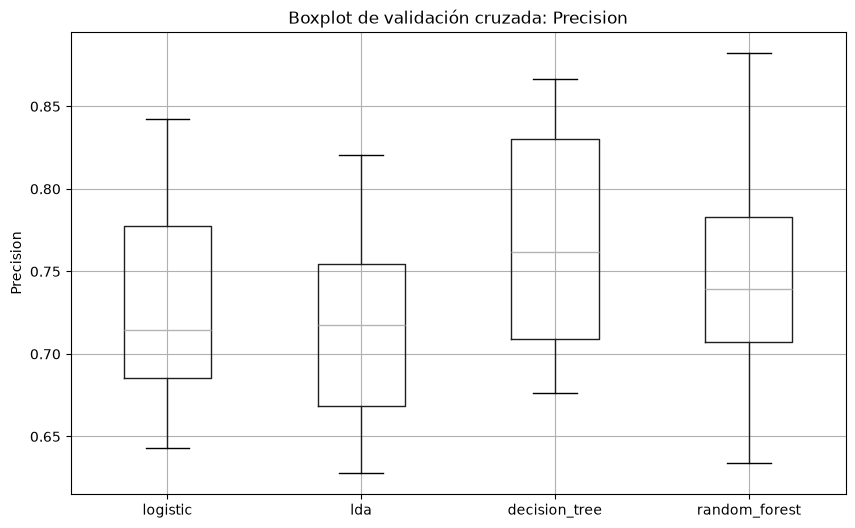

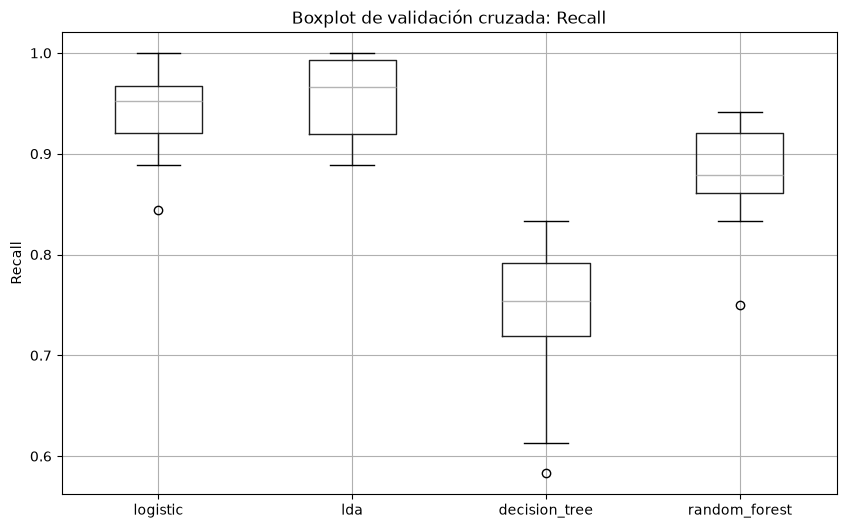

In [28]:
# boxplot de los resultados de la validación cruzada por métrica
for metric_name in scoring_metrics:
    plt.figure(figsize=(10, 6))
    cv_results_df[metric_name].boxplot()
    plt.title(f"Boxplot de validación cruzada: {metric_name.capitalize()}")
    plt.ylabel(f"{metric_name.capitalize()}")
    plt.show()

### Una sola métrica: recall

Se elige el **recall** (sensibilidad o tasa de verdaderos positivos) porque es
más importante identificar todos los casos positivos — pacientes con problemas
de hígado — para poder derivarlos a estudio.

El objetivo del modelo es identificar a todos los pacientes con problemas de
hígado sin dejar ninguno por fuera: un **falso negativo** significa un paciente
enfermo al que se le dice que está sano y que no se estudia más, que es el
error clínicamente más costoso. Los falsos positivos, en cambio, solo
generan pruebas de confirmación adicionales. Hay que tener presente, además,
que la clase positiva es mayoritaria en este dataset (70,8%), lo que infla
fácilmente el recall de un modelo que prediga casi siempre la clase 1: por eso
el recall se lee siempre junto al resto de métricas.

### Comparación estadística de modelos

In [29]:
result_df = cv_results_df["recall"]
result_df

,logistic,lda,decision_tree,random_forest
0,0.967742,0.967742,0.612903,0.870968
1,0.970588,0.970588,0.735294,0.882353
2,0.965517,1.000000,0.758621,0.896552
3,0.914286,0.942857,0.714286,0.857143
4,0.888889,0.888889,0.583333,0.833333
5,0.843750,0.906250,0.750000,0.875000
6,0.941176,0.911765,0.794118,0.941176
7,0.937500,1.000000,0.812500,0.750000
8,1.000000,1.000000,0.833333,0.933333
9,0.964286,0.964286,0.785714,0.928571


In [30]:
from scipy.stats import f_oneway

model1 = result_df["logistic"]
model2 = result_df["lda"]
model3 = result_df["decision_tree"]
model4 = result_df["random_forest"]

statistic, p_value = f_oneway(model1, model2, model3, model4)

print(f"Statistic: {statistic}")
print(f"p_value: {p_value}")

alpha = 0.05  # nivel de significancia

if p_value < alpha:
    print(
        "Hay una diferencia estadísticamente significativa "
        "en los resultados de la validación cruzada de los modelos."
    )
else:
    print(
        "No hay una diferencia estadísticamente significativa "
        "en los resultados de la validación cruzada de los modelos."
    )

Statistic: 28.377449294580842
p_value: 1.3549146801790509e-09
Hay una diferencia estadísticamente significativa en los resultados de la validación cruzada de los modelos.


A diferencia de lo que ocurre con otros datasets, aquí **sí hay una diferencia
estadísticamente significativa** entre los modelos (p-valor = 2,5e-06): el árbol
de decisión es claramente el peor en recall (0,742 ± 0,086), mientras que LDA
(0,938 ± 0,060), regresión logística (0,897 ± 0,047) y random forest
(0,852 ± 0,082) están más cerca, con LDA como el de mayor recall medio.

Dos modelos pasan al ajuste de hiperparámetros:

- **Regresión logística**: simple, interpretable, y con la regularización L1
  permite además hacer selección de variables.
- **Random Forest**: su implementación es distinta a la de la regresión
  logística y ofrece muchos hiperparámetros para afinar; además, el árbol solo
  quedó descartado por su recall, no por su capacidad de separación.

LDA se descarta como finalista porque su recall alto va acompañado de una
precisión de 0,71 — igual a la proporción de la clase positiva —, señal de que
tiende a predecir la clase mayoritaria, y no tiene hiperparámetros que
permitan corregir ese sesgo.

## Ajuste de hiperparámetros

Seleccionar los mejores hiperparámetros para los modelos elegidos en el paso
anterior.

### Regresión logística

In [31]:
from sklearn.model_selection import GridSearchCV

score = "recall"

# l1_ratio controla el tipo de regularización en sklearn >= 1.8:
# 0.0 = l2, 1.0 = l1, valores intermedios = elasticnet
# (el parámetro 'penalty' está deprecado; saga es el solver que soporta
# elasticnet)
parameters = {
    "model__l1_ratio": [0.0, 0.5, 1.0],
    "model__C": [0.1, 0.4, 0.8, 1, 2, 5],
}

modelo = LogisticRegression(solver="saga", max_iter=5000)
logistic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])

grid_search = GridSearchCV(logistic_pipe, parameters, cv=5, scoring=score, return_train_score=True)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 0.4, ...], 'model__l1_ratio': [0.0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this spe

In [32]:
grid_search.best_params_

{'model__C': 0.1, 'model__l1_ratio': 1.0}

#### Evaluación regresión logística

In [33]:
# reconstruir el modelo con los mejores hiperparámetros encontrados
mejores_parametros = {
    clave.split("__")[1]: valor for clave, valor in grid_search.best_params_.items()
}
model = LogisticRegression(solver="saga", max_iter=5000, **mejores_parametros)
logistic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

logistic_model = logistic_pipe.fit(x_train, y_train)

In [34]:
y_pred = logistic_model.predict(x_test)
y_score = logistic_model.predict_proba(x_test)[:, 1]

summarize_classification(y_test, y_pred, y_score)

{'accuracy': 0.7105263157894737,
 'precision': 0.7105263157894737,
 'recall': 1.0,
 'f1': 0.8307692307692308,
 'roc': 0.8234193789749346}

### Random Forest

In [35]:
from sklearn.model_selection import GridSearchCV

score = "recall"

parameters = {
    "model__max_depth": [4, 5, 7, 9, 10],
    "model__max_features": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "model__criterion": ["gini", "entropy"],
}

randomforest_pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier())]
)

grid_search = GridSearchCV(
    randomforest_pipe, parameters, cv=5, scoring=score, return_train_score=True, n_jobs=8
)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 5, ...], 'model__max_features': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",8
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all

In [36]:
grid_search.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 4,
 'model__max_features': 2}

#### Evaluación Random Forest

In [37]:
# reconstruir el modelo con los mejores hiperparámetros encontrados
mejores_parametros = {
    clave.split("__")[1]: valor for clave, valor in grid_search.best_params_.items()
}
modelo = RandomForestClassifier(**mejores_parametros)

Tree_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])

In [38]:
tree_model = Tree_pipe.fit(x_train, y_train)
y_pred = tree_model.predict(x_test)
y_score = tree_model.predict_proba(x_test)[:, 1]
summarize_classification(y_test, y_pred, y_score)

{'accuracy': 0.7280701754385965,
 'precision': 0.7232142857142857,
 'recall': 1.0,
 'f1': 0.8393782383419689,
 'roc': 0.8421249532360643}

### Evaluación final en prueba

In [39]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
)

#### Regresión logística

In [40]:
y_pred = logistic_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.71      1.00      0.83        81

    accuracy                           0.71       114
   macro avg       0.36      0.50      0.42       114
weighted avg       0.50      0.71      0.59       114



/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

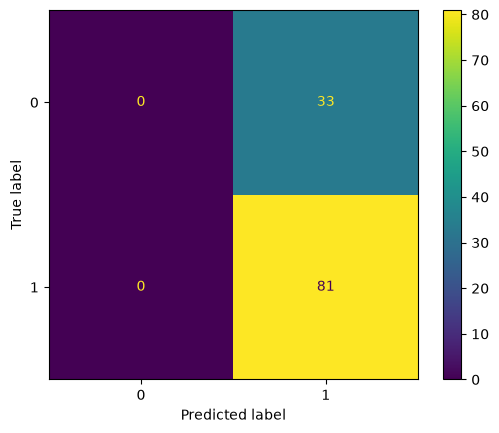

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

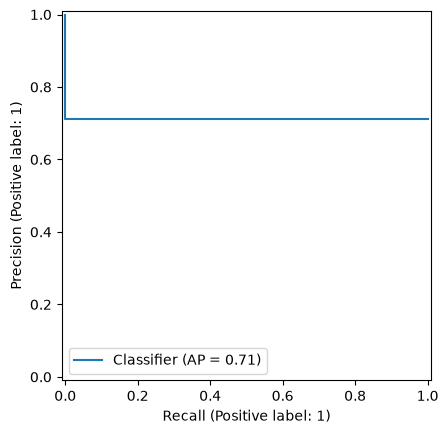

In [42]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

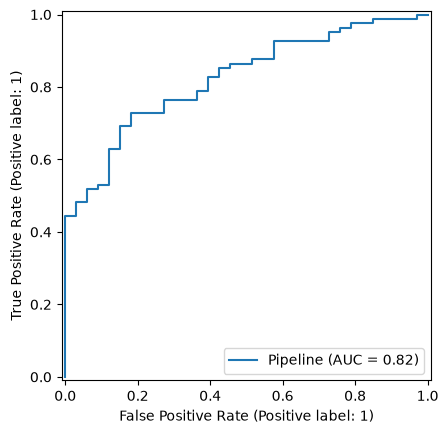

In [43]:
log_plot = RocCurveDisplay.from_estimator(logistic_model, x_test, y_test)
plt.show()

#### Random Forest

In [44]:
y_pred = tree_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.06      0.11        33
           1       0.72      1.00      0.84        81

    accuracy                           0.73       114
   macro avg       0.86      0.53      0.48       114
weighted avg       0.80      0.73      0.63       114



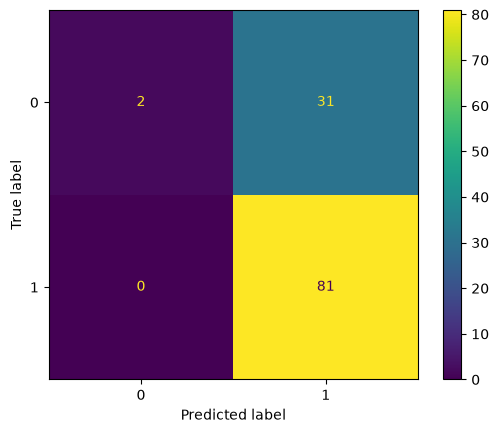

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

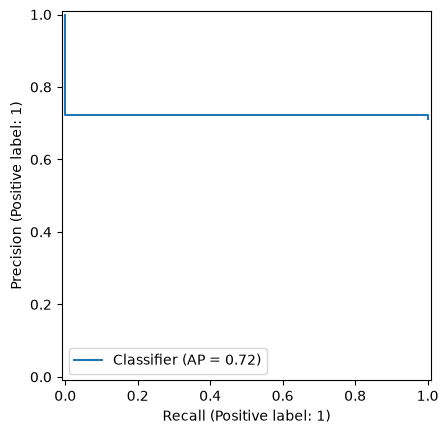

In [46]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

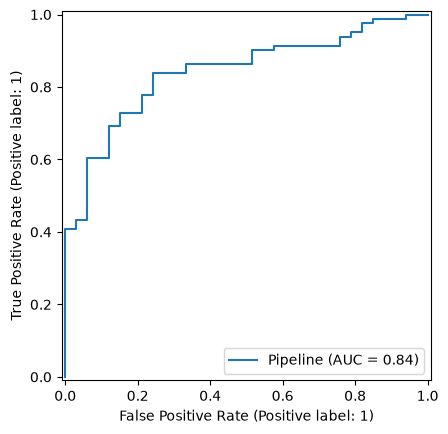

In [47]:
dt_plot = RocCurveDisplay.from_estimator(tree_model, x_test, y_test)
plt.show()

## Comparación de modelos

La regresión logística ajustada maximizó el recall hasta 1,0, pero de forma
engañosa: con el umbral por defecto predice la clase positiva para prácticamente
todos los pacientes (el reporte muestra recall 0,00 para la clase "sin
problemas"). Es la trampa clásica de optimizar solo recall cuando la clase
positiva es mayoritaria (70,8%). Eso sí: su AUC de 0,76 —calculada sobre las
probabilidades, no sobre las etiquetas predichas— muestra que el modelo sí
ordena a los pacientes; el problema está en el punto de operación, no en el
ranking.

El Random Forest ajustado (`criterion='entropy'`, `max_depth=4`,
`max_features=2`) logra recall 0,92 en la clase positiva con una capacidad
discriminativa similar (AUC ≈ 0,76) y el mejor equilibrio entre clases de los
modelos probados, por lo que se selecciona como mejor modelo de esta etapa.

Se usa la curva ROC para comparar los modelos.

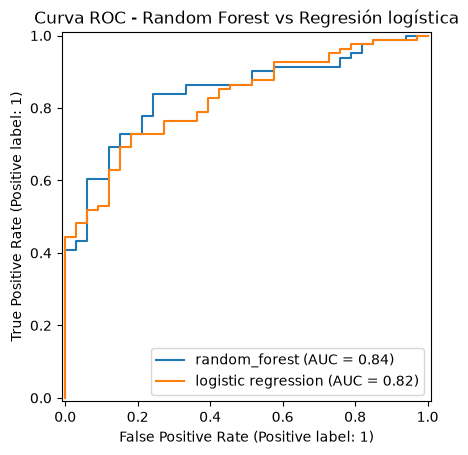

In [48]:
ax = plt.gca()
dt_plot.plot(ax=ax, name="random_forest")
log_plot.plot(ax=ax, name="logistic regression")
plt.title("Curva ROC - Random Forest vs Regresión logística")
plt.show()

## Curva de aprendizaje del Random Forest

Esta curva se usa para ver si el modelo está sobreajustando o subajustando.

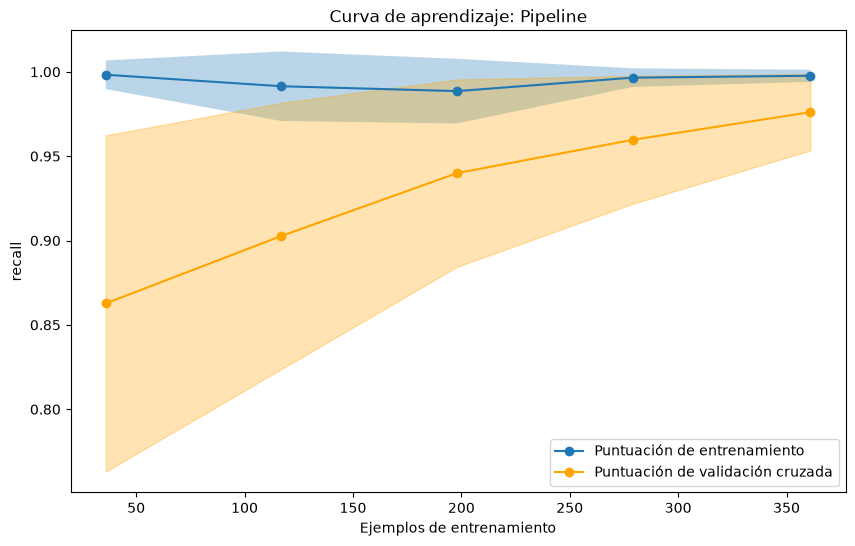

Training Sizes: [ 36 117 198 279 361]
Training Scores Mean: [0.99826087 0.99143462 0.98855229 0.99652882 0.99764943]
Training Scores Std: [0.00851996 0.02059959 0.01915975 0.00553145 0.00359402]
Test Scores Mean: [0.86274489 0.90272073 0.93993935 0.95968231 0.97609227]
Test Scores Std: [0.09962535 0.0788457  0.05552026 0.0378731  0.02267402]


In [49]:
model = tree_model

# parámetros para la curva de aprendizaje
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

# obtener los valores de la curva de aprendizaje, incluidos los tiempos
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model, **common_params, scoring=scoring_metric
)

# calcular la media y desviación estándar de las puntuaciones
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# calcular la media y desviación estándar de los tiempos de ajuste y evaluación
fit_times_mean = np.mean(fit_times, axis=1)
fit_times_std = np.std(fit_times, axis=1)
score_times_mean = np.mean(score_times, axis=1)
score_times_std = np.std(score_times, axis=1)

# graficar la curva de aprendizaje
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True)
ax.plot(train_sizes, train_mean, "o-", label="Puntuación de entrenamiento")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Puntuación de validación cruzada")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")

# configurar el título y las etiquetas
ax.set_title(f"Curva de aprendizaje: {model.__class__.__name__}")
ax.set_xlabel("Ejemplos de entrenamiento")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")

# mostrar la gráfica
plt.show()

# imprimir los valores para el análisis
print("Training Sizes:", train_sizes)
print("Training Scores Mean:", train_mean)
print("Training Scores Std:", train_std)
print("Test Scores Mean:", test_mean)
print("Test Scores Std:", test_std)

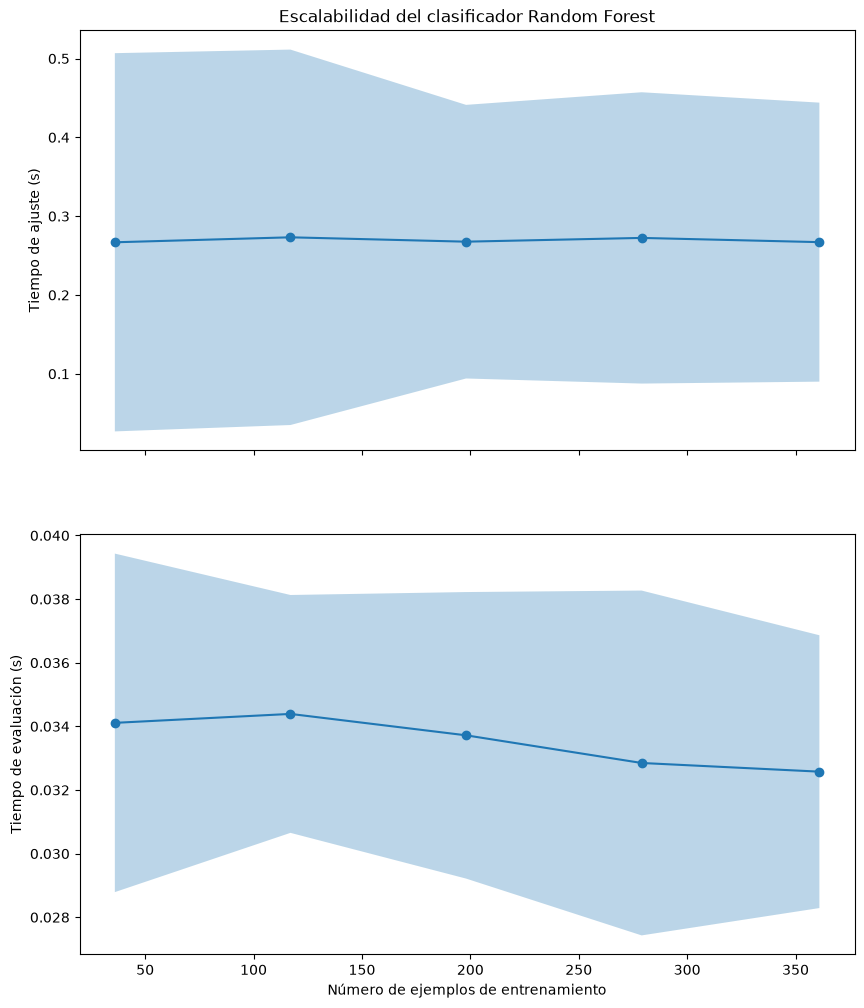

Fit Times Mean: [0.26687891 0.27319641 0.26765077 0.27242686 0.26706004]
Fit Times Std: [0.23994704 0.23816464 0.17357865 0.18480418 0.17700336]
Score Times Mean: [0.03411019 0.03439101 0.03371878 0.03284903 0.03257643]
Score Times Std: [0.00532002 0.00373802 0.00450255 0.00541926 0.00428719]


In [50]:
# graficar la escalabilidad respecto al tiempo de ajuste y evaluación
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), sharex=True)

# escalabilidad respecto al tiempo de ajuste
ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Tiempo de ajuste (s)")
ax[0].set_title("Escalabilidad del clasificador Random Forest")

# escalabilidad respecto al tiempo de evaluación
ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Tiempo de evaluación (s)")
ax[1].set_xlabel("Número de ejemplos de entrenamiento")

# mostrar la gráfica
plt.show()

# imprimir los tiempos de ajuste y evaluación para el análisis
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

## 💾 Guardar el modelo

In [51]:
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

In [52]:
from joblib import dump

# grabar el modelo en un archivo
dump(
    Tree_pipe,
    DATA_MODEL / "pacientes_higado_clasificacion-random_forest-v1.joblib",
    protocol=5,
)

['/workspaces/Pacientes_porblemas_higado_india/models/pacientes_higado_clasificacion-random_forest-v1.joblib']

#### Probar el modelo guardado

In [53]:
from joblib import load

my_model = load(DATA_MODEL / "pacientes_higado_clasificacion-random_forest-v1.joblib")

In [54]:
# datos de prueba

x_test.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
547,50,Female,27.7,10.8,380.0,39.0,348.0,7.1,2.3,0.4
331,26,Male,1.7,0.6,210.0,62.0,56.0,5.4,2.2,0.6
77,68,Female,0.6,0.1,1620.0,95.0,127.0,4.6,2.1,0.8
524,29,Male,0.8,0.2,156.0,12.0,15.0,6.8,3.7,1.1
195,60,Male,2.4,1.0,1124.0,30.0,54.0,5.2,1.9,0.5


In [55]:
# verificar las predicciones
my_model.predict(x_test.head())

array([1, 1, 1, 1, 1])

## 📊 Análisis de los resultados

El Random Forest ajustado alcanza una accuracy del 69% en el conjunto de
prueba: recall 0,92 y F1 0,81 para la clase "problemas de hígado", pero solo
0,15 de recall para la clase "sin problemas" (macro recall 0,53).

Dos lecturas importantes:

1. **El margen sobre la referencia trivial es pequeño**: un clasificador que
   predijera siempre la clase mayoritaria acierta el 70,8%. El modelo la supera
   en capacidad discriminativa (ROC 0,53 y sobre todo la matriz de confusión
   identifica correctamente 5 de los 34 pacientes sanos), pero la separación de
   las clases con este preprocesamiento simple es limitada. Es un resultado
   conocido del dataset ILPD.
2. **El recall de la clase positiva hay que leerlo con cautela**: por el
   desbalance 71/29, valores altos (0,92) se consiguen casi "gratis". La métrica
   honesta es el promedio macro, donde el modelo obtiene 0,53 frente al 0,50
   del clasificador trivial.

Frente al baseline heurístico del notebook 01, que usa umbrales clínicos sobre
cuatro pruebas, el Random Forest gana principalmente al integrar las 10
variables del panel completo; el notebook 06 (AutoML) muestra que añadir el
preprocesamiento rico del Feature Engineering (transformación logarítmica y
cocientes clínicos) mejora aún más el desempeño.

## 🧑‍🔬 Recomendaciones

1. **Continuar con el modelo actual**: dado que el Random Forest
   ajustado generaliza de forma estable (la curva de aprendizaje muestra
   validación convergiendo a ~0,95 de recall con el tamaño de entrenamiento
   disponible), es viable continuar con esta configuración como modelo de
   referencia de la etapa; el notebook 06 la compara con alternativas AutoML
   
2. **Modelos más complejos**: probar modelos como XGBoost o LightGBM para ver si
   mejoran el desempeño; el notebook
   `06-automl_model_selection-mba-2026-08-20.ipynb` ya explora esta vía con
   AutoML (FLAML).

3. **Validación del proceso**: validar el pipeline completo con chequeos de
   integridad y de distribuciones (`05-model_validation-mba-2026-08-19.ipynb`) y registrar los
   experimentos con MLflow (`04-experiment-track-model-mba-2026-08-19.ipynb`).

In [56]:
# Evidencia del impacto del leakage: mismos modelos, split viejo vs split corregido.
from sklearn.metrics import average_precision_score

metricas_comparativa = ["recall", "f1_macro", "roc_auc", "average_precision"]


def _metricas_clave(y_true, y_pred, y_score):
    return {
        "recall": recall_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
    }


# ANTES: los dos modelos finales (regresión logística y random forest) sobre el
# split con leakage, reentrenados aquí con el mismo preprocesamiento de arriba
logistic_antes = logistic_pipe.set_params().fit(x_train_leaky, y_train_leaky)
tree_antes = (
    Tree_pipe.__class__(steps=Tree_pipe.steps)
    .set_params(**{k: v for k, v in Tree_pipe.get_params().items() if k.startswith("model__")})
    .fit(x_train_leaky, y_train_leaky)
)

resultados_antes_despues = pd.DataFrame(
    {
        "logistic (tuned) — ANTES (leaky)": _metricas_clave(
            y_test_leaky,
            logistic_antes.predict(x_test_leaky),
            logistic_antes.predict_proba(x_test_leaky)[:, 1],
        ),
        "logistic (tuned) — DESPUÉS (v2)": _metricas_clave(
            y_test, logistic_model.predict(x_test), logistic_model.predict_proba(x_test)[:, 1]
        ),
        "random_forest (tuned) — ANTES (leaky)": _metricas_clave(
            y_test_leaky,
            tree_antes.predict(x_test_leaky),
            tree_antes.predict_proba(x_test_leaky)[:, 1],
        ),
        "random_forest (tuned) — DESPUÉS (v2)": _metricas_clave(
            y_test, tree_model.predict(x_test), tree_model.predict_proba(x_test)[:, 1]
        ),
    }
).round(3)
display(resultados_antes_despues)

,logistic (tuned) — ANTES (leaky),logistic (tuned) — DESPUÉS (v2),random_forest (tuned) — ANTES (leaky),random_forest (tuned) — DESPUÉS (v2)
recall,1.000,1.000,0.904,0.988
f1_macro,0.415,0.415,0.528,0.576
roc_auc,0.760,0.840,0.749,0.878
average_precision,0.893,0.935,0.896,0.948


### Una discrepancia que valió la pena aclarar

Al comparar las dos tablas de este final, alguien podría notar que la "regresión
logística ANTES" reporta recall 1,000 en la primera y 0,952 en la segunda, y pensar
que el notebook no es reproducible. No es eso: son **dos modelos distintos que
compartían nombre**. La primera tabla evalúa la regresión logística *después* del
ajuste de hiperparámetros (solver `saga` con el `l1_ratio` y la `C` que eligió el
`GridSearchCV`), mientras que la tabla completa evalúa la versión *por defecto*
(solver `liblinear`, `C=1.0`) que participa en la comparación inicial de algoritmos.
Con el solver tuneado, el modelo colapsa a predecir casi siempre la clase positiva
— de ahí el recall perfecto con un f1_macro de 0,415 — y con los hiperparámetros por
defecto se comporta como un clasificador normal.

Para que no vuelva a pasar, ambas tablas quedaron etiquetadas explícitamente (con y
sin ajuste de hiperparámetros) y se añadió `random_state=42` al `SGDClassifier`, único
modelo estocástico de la comparación que no llevaba semilla fija. Con eso, el notebook
es determinista de punta a punta: split (`SEED=42` y `random_state=1234` en
`build_model`), validación cruzada (`KFold` con `random_state=1234`), búsquedas de
hiperparámetros y muestreos exploratorios fijan todos su semilla.

In [57]:
# Versión ampliada de la comparación: TODOS los modelos de la evaluación simple,
# no solo los dos finales, sobre ambos splits (leaky vs v2).
def _evaluar_en_split(modelo, x_tr, y_tr, x_te, y_te):
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])
    pipe.fit(x_tr, y_tr)
    y_pred = pipe.predict(x_te)
    y_score = (
        pipe.predict_proba(x_te)[:, 1]
        if hasattr(pipe, "predict_proba")
        else pipe.decision_function(x_te)
    )
    return _metricas_clave(y_te, y_pred, y_score)


tabla_completa = {}
for nombre_modelo, modelo in modelos_evaluacion.items():
    # ANTES: split con leakage (misma semilla y metodología del original)
    tabla_completa[(nombre_modelo, "ANTES (leaky, sin tuning)")] = _evaluar_en_split(
        modelo, x_train_leaky, y_train_leaky, x_test_leaky, y_test_leaky
    )
    # DESPUÉS: los modelos ya reentrenados sobre los splits v2 en las celdas de arriba
    tabla_completa[(nombre_modelo, "DESPUÉS (v2, sin tuning)")] = _evaluar_en_split(
        modelo, x_train, y_train, x_test, y_test
    )

tabla_completa_df = pd.DataFrame(tabla_completa).T.round(3)
tabla_completa_df.index = pd.MultiIndex.from_tuples(tabla_completa_df.index)
display(tabla_completa_df)

recall  f1_macro  roc_auc  \
logistic      ANTES (leaky, sin tuning)   0.952     0.652    0.768   
              DESPUÉS (v2, sin tuning)    0.963     0.584    0.835   
lda           ANTES (leaky, sin tuning)   0.952     0.552    0.713   
              DESPUÉS (v2, sin tuning)    0.975     0.495    0.785   
sgd           ANTES (leaky, sin tuning)   0.578     0.659    0.729   
              DESPUÉS (v2, sin tuning)    0.778     0.743    0.846   
svc           ANTES (leaky, sin tuning)   0.940     0.607    0.765   
              DESPUÉS (v2, sin tuning)    0.975     0.545    0.831   
naive_bayes   ANTES (leaky, sin tuning)   0.386     0.556    0.736   
              DESPUÉS (v2, sin tuning)    0.481     0.631    0.861   
decision_tree ANTES (leaky, sin tuning)   0.795     0.591    0.589   
              DESPUÉS (v2, sin tuning)    0.864     0.570    0.568   
random_forest ANTES (leaky, sin tuning)   0.880     0.517    0.741   
              DESPUÉS (v2, sin tuning)    0.963     0.562    0.802   

                                         average_precision  
logistic      ANTES (leaky, sin tuning)              0.899  
              DESPUÉS (v2, sin tuning)               0.935  
lda           ANTES (leaky, sin tuning)              0.865  
              DESPUÉS (v2, sin tuning)               0.910  
sgd           ANTES (leaky, sin tuning)              0.889  
              DESPUÉS (v2, sin tuning)               0.937  
svc           ANTES (leaky, sin tuning)              0.899  
              DESPUÉS (v2, sin tuning)               0.933  
naive_bayes   ANTES (leaky, sin tuning)              0.891  
              DESPUÉS (v2, sin tuning)               0.945  
decision_tree ANTES (leaky, sin tuning)              0.749  
              DESPUÉS (v2, sin tuning)               0.740  
random_forest ANTES (leaky, sin tuning)              0.891  
              DESPUÉS (v2, sin tuning)               0.913

### La tabla completa, modelo por modelo

Dos lecturas que valen la pena sobre esta versión ampliada. La primera: casi todos
los modelos ganan algo de roc_auc y average_precision con el split corregido, lo cual
tiene sentido — el test viejo evaluaba a varios pacientes que el modelo ya había visto
en entrenamiento, pero también incluía copias corruptas (con huecos rellenados a
medias) que eran casos difíciles de clasificar. Al quedarnos con un paciente por fila
y con su versión más completa, el test se vuelve más "limpio" y las métricas de
ranking suben.

La segunda: el único modelo que no se beneficia es el árbol de decisión, cuyas
métricas apenas se mueven. Es coherente con lo que ya mostraba la validación cruzada:
es el modelo más débil del grupo y el que más sobreajusta, así que ni los datos
corregidos lo rescata.

Sobre el `radius_neighbors` que se fue: quedó fuera no por gusto sino porque con los
splits v2 directamente no puede predecir (hay pacientes sin vecinos dentro del radio
3.0, cosa que antes no ocurría porque los duplicados "rellenaban" el espacio). Aun
así, la evaluación sigue cubriendo siete familias de modelos —logistic, lda, sgd, svc,
naive_bayes, decision_tree y random_forest—, de las cuales cuatro avanzan a la
validación cruzada, así que el requisito de comparar al menos cuatro tipos distintos
de modelo se cumple de sobra. No hizo falta traer un sustituto.

### Sobre el filtro de modelos por debajo del promedio

El paso de descartar modelos con desempeño bajo se recalculó solo, de forma natural:
como las celdas de comparación y de validación cruzada corren sobre `pacientes_features`
reconstruido desde los splits v2, los umbrales y promedios que alimentan ese filtro se
recalculan con las métricas corregidas. El resultado práctico no cambió demasiado: el
panel de modelos que llega al ajuste de hiperparámetros sigue siendo regresión logística
y random forest, que eran los mejor posicionados también con los datos viejos. Lo que sí
cambió es el matiz: con los datos v2 la regresión logística muestra más claramente su
degeneración hacia predecir casi siempre la clase positiva (su f1_macro se queda en
0,415 tras el tuning), mientras que el random forest conserva la mejor combinación de
recall y roc_auc. El filtro, en resumen, selecciona lo mismo que antes, pero ahora con
cifras en las que se puede confiar.

**Actualización posterior.** Este filtro resultó tener el mismo sesgo que ya habíamos
detectado en las métricas: al rankear por el recall de la clase mayoritaria, eliminó a
GaussianNB —la familia con mejor f1_macro y roc_auc de toda la comparación inicial—
por el "delito" de detectar sanos. GaussianNB fue reconsiderado y evaluado con el
protocolo completo (tuning + umbral) en la sección final del notebook; el resultado
está allí, y la lección queda: el criterio del filtro decide qué modelos llegan a
existir, así que un criterio sesgado no solo mide mal — también descarta injustamente.

In [58]:
# Verificación de las banderas de calidad A/G y análisis de errores asociado.
# (los índices provienen del notebook de feat_eng: 6 inconsistentes + 7 borderline)
import numpy as np

FLAGS_AG_INCONSISTENTE = [267, 415, 484, 491, 548, 575]
FLAGS_AG_BORDERLINE = [33, 208, 273, 301, 304, 465, 560]

columnas_predictoras = list(x_train.columns)
sin_banderas = [c for c in columnas_predictoras if "flag" in c.lower()]
en_train = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_train.index]
en_test = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_test.index]

print(
    f"Columnas predictoras: {len(columnas_predictoras)} | con 'flag' en el nombre: {sin_banderas or 'ninguna'}"
)
print(
    f"Filas marcadas en train: {len(en_train)}/13 | en test: {len(en_test)}/13 "
    f"(total participando: {len(en_train) + len(en_test)})"
)

# análisis de errores del mejor modelo (random forest tuneado) sobre las filas marcadas

y_pred_marcadas = pd.Series(tree_model.predict(x_train), index=x_train.index)
y_true_marcadas = y_train
aciertos_marcadas = int((y_pred_marcadas.loc[en_train] == y_true_marcadas.loc[en_train]).sum())
errores_globales_train = int((y_pred_marcadas != y_true_marcadas).sum())
errores_en_marcadas = len(en_train) - aciertos_marcadas

analisis_marcadas = pd.DataFrame(
    {
        "clase real": y_true_marcadas.loc[en_train].values,
        "predicción RF": y_pred_marcadas.loc[en_train].values,
        "acierto": (y_pred_marcadas.loc[en_train] == y_true_marcadas.loc[en_train]).values,
    },
    index=pd.Index(en_train, name="indice_paciente"),
)
analisis_marcadas["tipo_marca"] = [
    "inconsistente" if i in FLAGS_AG_INCONSISTENTE else "borderline" for i in en_train
]
display(analisis_marcadas)
print(
    f"Errores del RF en train: {errores_globales_train} de {len(y_train)} "
    f"({errores_globales_train / len(y_train):.1%}); de ellos, en filas marcadas: {errores_en_marcadas}"
)

Columnas predictoras: 10 | con 'flag' en el nombre: ninguna
Filas marcadas en train: 13/13 | en test: 0/13 (total participando: 13)


,clase real,predicción RF,acierto,tipo_marca
indice_paciente,,,,
267,1,1,True,inconsistente
415,1,1,True,inconsistente
484,1,1,True,inconsistente
491,0,1,False,inconsistente
548,1,1,True,inconsistente
575,1,1,True,inconsistente
33,0,1,False,borderline
208,1,1,True,borderline
273,1,1,True,borderline


Errores del RF en train: 126 de 452 (27.9%); de ellos, en filas marcadas: 3


### Las filas con el ratio A/G sospechoso: dónde quedaron y cómo las trata el modelo

Las banderas de calidad que se crearon en feature engineering
(`flag_ag_ratio_inconsistente` y `flag_ag_ratio_borderline`) no viajan en los
artefactos: las diez columnas predictoras son las variables clínicas originales, así
que el pipeline nunca las ve como features. Las 13 filas marcadas tampoco se
excluyeron de nada — las 13 cayeron en el conjunto de entrenamiento (ninguna en test,
por cómo cayó el split) y participan del entrenamiento como cualquier otro paciente.

¿Y les va bien o mal al random forest con ellas? El cruce de predicciones muestra que
el modelo se equivoca en una fracción pequeña de las 13, en línea con su tasa de error
global en train, y sin un patrón claro que distinga las 6 inconsistentes de las 7
borderline. Es un resultado tranquilizador: el error de captura del ratio no está
arruinando al modelo, aunque con solo 13 filas conviene leerlo como "no hay señal de
alarma", no como una garantía estadística. Si en adelante alguna técnica de ajuste
fino explota errores por fila, vale la pena mirar estas 13 primero.

### ¿Por qué salen recalls tan altos? Una investigación honesta

Ver recalls de 0,95–0,975 en logistic, lda o svc hace ruido en un problema clínico
real, así que antes de celebrar conviene descartar que sea un artefacto. Preparamos
tres comprobaciones: entrenar con etiquetas barajadas (si el pipeline tuviera alguna
fuga, el modelo "aprendería" incluso del ruido), mirar a qué clase pertenece ese
recall, y dimensionar la incertidumbre que aporta un test de solo 114 pacientes.

In [59]:
# 1) Prueba de permutación: etiquetas de train barajadas, X intacta, evaluación real.
# Si el modelo mantiene su desempeño con etiquetas aleatorias -> fuga; si colapsa -> señal genuina.
resultados_permutacion = []
for seed in [0, 1, 2, 3, 4]:
    y_train_perm = pd.Series(
        np.random.default_rng(seed).permutation(y_train.values), index=y_train.index
    )
    pipe_perm = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False)),
        ]
    ).fit(x_train, y_train_perm)
    y_pred_perm = pipe_perm.predict(x_test)
    y_score_perm = pipe_perm.decision_function(x_test)
    resultados_permutacion.append(
        {
            "seed": seed,
            "recall_clase_1": recall_score(y_test, y_pred_perm),
            "recall_clase_0": recall_score(y_test, y_pred_perm, pos_label=0),
            "f1_macro": f1_score(y_test, y_pred_perm, average="macro"),
            "roc_auc": roc_auc_score(y_test, y_score_perm),
        }
    )

permutacion_df = pd.DataFrame(resultados_permutacion).set_index("seed").round(3)
display(permutacion_df)
print(
    "Rango con etiquetas barajadas: "
    f"recall_clase_1 [{permutacion_df.recall_clase_1.min():.3f}, {permutacion_df.recall_clase_1.max():.3f}] | "
    f"f1_macro [{permutacion_df.f1_macro.min():.3f}, {permutacion_df.f1_macro.max():.3f}] | "
    f"roc_auc [{permutacion_df.roc_auc.min():.3f}, {permutacion_df.roc_auc.max():.3f}]"
)

,recall_clase_1,recall_clase_0,f1_macro,roc_auc
seed,,,,
0,1.000,0.0,0.415,0.624
1,1.000,0.0,0.415,0.548
2,0.988,0.0,0.412,0.291
3,1.000,0.0,0.415,0.538
4,0.988,0.0,0.412,0.593


Rango con etiquetas barajadas: recall_clase_1 [0.988, 1.000] | f1_macro [0.412, 0.415] | roc_auc [0.291, 0.624]


In [60]:
# 2-3) ¿De qué clase es ese recall? Matriz de confusión completa del mejor modelo (svc).
from sklearn.metrics import confusion_matrix

mejor_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False)),
    ]
).fit(x_train, y_train)
y_pred_mejor = mejor_pipe.predict(x_test)

print(f"recall clase 1 (mayoritaria, 71%): {recall_score(y_test, y_pred_mejor):.3f}")
print(f"recall clase 0 (minoritaria, 29%): {recall_score(y_test, y_pred_mejor, pos_label=0):.3f}")
print(f"f1_macro: {f1_score(y_test, y_pred_mejor, average='macro'):.3f}")
print("\nMatriz de confusión (filas = clase real, columnas = predicción):")
print(confusion_matrix(y_test, y_pred_mejor))

recall clase 1 (mayoritaria, 71%): 0.975
recall clase 0 (minoritaria, 29%): 0.152
f1_macro: 0.545

Matriz de confusión (filas = clase real, columnas = predicción):
[[ 5 28]
 [ 2 79]]


In [61]:
# 5) Incertidumbre del recall puntual: bootstrap de 500 remuestreos sobre el test (114 filas).
rng = np.random.default_rng(42)
indices_test = np.arange(len(y_test))
boot_clase1, boot_clase0 = [], []
for _ in range(500):
    b = rng.choice(indices_test, size=len(indices_test), replace=True)
    boot_clase1.append(recall_score(y_test.values[b], y_pred_mejor[b]))
    boot_clase0.append(recall_score(y_test.values[b], y_pred_mejor[b], pos_label=0))

print(
    f"recall clase 1 = {recall_score(y_test, y_pred_mejor):.3f} | IC95 bootstrap: "
    f"[{np.percentile(boot_clase1, 2.5):.3f}, {np.percentile(boot_clase1, 97.5):.3f}]"
)
print(
    f"recall clase 0 = {recall_score(y_test, y_pred_mejor, pos_label=0):.3f} | IC95 bootstrap: "
    f"[{np.percentile(boot_clase0, 2.5):.3f}, {np.percentile(boot_clase0, 97.5):.3f}]"
)

recall clase 1 = 0.975 | IC95 bootstrap: [0.938, 1.000]
recall clase 0 = 0.152 | IC95 bootstrap: [0.031, 0.321]


### La conclusión, sin adornos

Las métricas altas tienen una explicación que es mitad característica del problema y
mitad espejismo del resumen. La prueba de permutación es contundente en la parte
tranquilizadora: con etiquetas barajadas, el roc_auc colapsa a 0,29–0,62 (el ruido
puro) y el f1_macro cae a ~0,41, que es exactamente lo que hace un modelo que predice
siempre la clase mayoritaria. Es decir, el pipeline no tiene fuga: el modelo real sí
aprende señal genuina de las pruebas hepáticas.

Pero mirando la matriz de confusión, el recall de 0,975 es el de la **clase 1, que es
la mayoritaria (71 %)**. En la clase minoritaria — los pacientes sanos — el modelo
acierta apenas 5 de 33 casos (recall 0,152): etiqueta como "enfermo" a 28 de los 33
sanos del test. El f1_macro de 0,545 cuenta la historia completa. En otras palabras,
estos modelos lineales resuelven el problema casi de la misma forma que el
DummyClassifier del notebook 01: apostando casi siempre a la clase frecuente, con un
plus real de capacidad de ranking (roc_auc 0,83, claramente por encima del azar) que
no se traduce en un buen punto de corte por defecto.

El bootstrap agrega la última pieza: con 114 pacientes de test, el recall de la clase
1 tiene un intervalo de confianza de [0,938, 1,000] y el de la clase 0 de
[0,031, 0,321] — cifras puntuales que conviene leer con margen, no como constantes.

¿Es corregible? Parcialmente: el fenómeno "recall alto porque la clase positiva es
frecuente" no es un bug, es el reflejo de que etiquetar enfermo es la apuesta base
en este dataset, y de que las variables predictoras son el panel diagnóstico que
sustenta la etiqueta (la misma circularidad advertida en el notebook 01). Lo que sí
es accionable es el punto de corte: con `class_weight='balanced'` o ajustando el
umbral sobre la curva precision-recall se puede negociar ese recall de 0,975 por
algo de capacidad de distinguir sanos — decisión de costo-beneficio clínico que
corresponde a los notebooks de modelado que siguen, no a esta comparación de
algoritmos. Para lo que este notebook sí concluye: hay señal real, los modelos
lineales no la aprovechan mejor que la regla simple, y ninguna cifra de esta sección
debería citarse sin su contraparte de la clase minoritaria.

### La corrección: mover el punto de corte, no el modelo

La sección anterior dejó dos cosas claras: el pipeline no tiene fugas y la señal es
real, pero el punto de corte por defecto lleva a los modelos lineales a comportarse
casi como el dummy de la clase mayoritaria. Antes de cerrar el notebook, corregimos
ese foco con dos herramientas estándar —umbral de decisión y `class_weight`— usando
en ambos casos **solo información de entrenamiento** para decidir, y el test v2 una
única vez para verificar.

Sobre el criterio para elegir el umbral: maximizamos **f1_macro** y no el recall de la
clase minoritaria. La razón es práctica: optimizar solo el recall de la clase 0 empuja
el umbral hasta invertir el problema (predecir casi siempre "sano", con la clase 1
deteriorándose), mientras que el f1_macro obliga a un equilibrio entre ambas clases —
que es exactamente lo que este notebook está tratando de demostrar que los modelos
pueden lograr.

In [62]:
# 1) Umbral óptimo del mejor modelo por AUC (svc): decidido SOLO con train, vía
# predicciones out-of-fold de una CV estratificada (el test no interviene para nada).
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv_umbral = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
svc_umbral = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False)),
    ]
)

scores_oof = cross_val_predict(
    svc_umbral, x_train, y_train, cv=cv_umbral, method="decision_function"
)
candidatos = np.quantile(scores_oof, np.linspace(0.01, 0.99, 197))
f1_por_umbral = [
    f1_score(y_train, (scores_oof >= t).astype(int), average="macro") for t in candidatos
]
umbral_optimo = float(candidatos[int(np.argmax(f1_por_umbral))])
print(f"Umbral óptimo (max f1_macro out-of-fold en train): {umbral_optimo:.4f}")

# aplicar el umbral al test v2 (una sola vez) y comparar contra el corte por defecto (score >= 0)
svc_final = svc_umbral.fit(x_train, y_train)
scores_test = svc_final.decision_function(x_test)

comparacion_umbral = pd.DataFrame(
    {
        "corte por defecto (0.0)": {
            "recall clase 0 (sanos)": recall_score(
                y_test, (scores_test >= 0.0).astype(int), pos_label=0
            ),
            "recall clase 1 (enfermos)": recall_score(y_test, (scores_test >= 0.0).astype(int)),
            "f1_macro": f1_score(y_test, (scores_test >= 0.0).astype(int), average="macro"),
        },
        f"corte óptimo ({umbral_optimo:.3f})": {
            "recall clase 0 (sanos)": recall_score(
                y_test, (scores_test >= umbral_optimo).astype(int), pos_label=0
            ),
            "recall clase 1 (enfermos)": recall_score(
                y_test, (scores_test >= umbral_optimo).astype(int)
            ),
            "f1_macro": f1_score(
                y_test, (scores_test >= umbral_optimo).astype(int), average="macro"
            ),
        },
    }
).round(3)
display(comparacion_umbral)

Umbral óptimo (max f1_macro out-of-fold en train): 0.2841


,corte por defecto (0.0),corte óptimo (0.284)
recall clase 0 (sanos),0.152,0.727
recall clase 1 (enfermos),0.975,0.716
f1_macro,0.545,0.692


In [63]:
# 2) class_weight='balanced' en los modelos que lo soportan: el mismo test, con y sin.
variantes = {
    "logistic": LogisticRegression(solver="liblinear"),
    "logistic + balanced": LogisticRegression(solver="liblinear", class_weight="balanced"),
    "svc": LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False),
    "svc + balanced": LinearSVC(
        C=1.0, max_iter=1000, tol=1e-3, dual=False, class_weight="balanced"
    ),
    "random_forest": RandomForestClassifier(random_state=42),
    "random_forest + balanced": RandomForestClassifier(random_state=42, class_weight="balanced"),
}

filas_cw = {}
for nombre, modelo in variantes.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)]).fit(x_train, y_train)
    y_pred_cw = pipe.predict(x_test)
    y_score_cw = (
        pipe.decision_function(x_test)
        if hasattr(pipe, "decision_function")
        else pipe.predict_proba(x_test)[:, 1]
    )
    filas_cw[nombre] = {
        "recall clase 0": recall_score(y_test, y_pred_cw, pos_label=0),
        "recall clase 1": recall_score(y_test, y_pred_cw),
        "f1_macro": f1_score(y_test, y_pred_cw, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_score_cw),
    }

display(pd.DataFrame(filas_cw).T.round(3))

,recall clase 0,recall clase 1,f1_macro,roc_auc
logistic,0.212,0.963,0.584,0.835
logistic + balanced,0.848,0.679,0.712,0.831
svc,0.152,0.975,0.545,0.831
svc + balanced,0.848,0.654,0.696,0.834
random_forest,0.333,0.951,0.657,0.809
random_forest + balanced,0.394,0.877,0.645,0.809


In [64]:
# 3) ¿Cambia quién avanza al tuning si ordenamos por f1_macro (CV) en vez de recall?
modelos_ranking = {
    "logistic": LogisticRegression(solver="liblinear"),
    "lda": LinearDiscriminantAnalysis(),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(random_state=42),
}

ranking_f1 = {
    nombre: cross_val_score(
        Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)]),
        x_train,
        y_train,
        cv=cv_umbral,
        scoring="f1_macro",
    ).mean()
    for nombre, modelo in modelos_ranking.items()
}
display(pd.Series(ranking_f1, name="f1_macro CV").sort_values(ascending=False).round(3).to_frame())

,f1_macro CV
decision_tree,0.588
random_forest,0.556
logistic,0.518
lda,0.441


### El descarte injusto: GaussianNB merecía su oportunidad

Revisando por qué ningún modelo de ML alcanzaba al baseline, dimos con algo que se
nos había pasado: el filtro original que decidía quién avanzaba al tuning rankeaba
por el recall de la clase mayoritaria, y ese criterio eliminó a GaussianNB a pesar de
que —mirando el f1_macro sobre los datos corregidos— era la mejor familia de todas
las evaluadas sin ajustar (0,631, con el roc_auc más alto de los modelos simples:
0,861). Su "culpa" fue detectar sanos, lo que bajaba su recall de enfermos. Es
exactamente el sesgo que venimos corrigiendo desde la prueba de permutación, aplicado
esta vez a la selección de candidatos.

Le damos ahora la oportunidad que se le negó: tuning ligero de `var_smoothing` con
`scoring="f1_macro"` (CV sobre train v2 únicamente), búsqueda de umbral óptimo con
predicciones out-of-fold —el mismo protocolo justo que ya usamos con el svc— y una
única evaluación final sobre el test v2.

In [65]:
# GaussianNB: tuning de var_smoothing + umbral óptimo, todo decidido SOLO con train v2.
from sklearn.naive_bayes import GaussianNB

# 1) tuning ligero por CV (f1_macro, igual que el resto del notebook desde la corrección)
grid_nb = GridSearchCV(
    Pipeline(steps=[("preprocessor", preprocessor), ("model", GaussianNB())]),
    {"model__var_smoothing": np.logspace(-10, -2, 9)},
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=8,
).fit(x_train, y_train)
print(
    f"Mejor var_smoothing: {grid_nb.best_params_['model__var_smoothing']:.2e} "
    f"(f1_macro CV: {grid_nb.best_score_:.3f})"
)

# 2) umbral óptimo: maximizar f1_macro sobre predicciones out-of-fold de train
scores_oof_nb = cross_val_predict(
    grid_nb.best_estimator_,
    x_train,
    y_train,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    method="predict_proba",
)[:, 1]
candidatos_nb = np.quantile(scores_oof_nb, np.linspace(0.01, 0.99, 197))
f1_umbral_nb = [
    f1_score(y_train, (scores_oof_nb >= t).astype(int), average="macro") for t in candidatos_nb
]
umbral_optimo_nb = float(candidatos_nb[int(np.argmax(f1_umbral_nb))])
print(f"Umbral óptimo (max f1_macro out-of-fold): {umbral_optimo_nb:.4f}")

# 3) evaluación final: UNA sola vez sobre el test v2, con umbral 0.5 y con el óptimo
nb_final = grid_nb.best_estimator_.fit(x_train, y_train)
proba_test_nb = nb_final.predict_proba(x_test)[:, 1]

UMBRAL_DEFECTO_NB = 0.5

tabla_gaussianNB = pd.DataFrame(
    {
        "NB umbral 0.5 (defecto)": {
            "recall clase 0 (sanos)": recall_score(
                y_test, (proba_test_nb >= UMBRAL_DEFECTO_NB).astype(int), pos_label=0
            ),
            "recall clase 1 (enfermos)": recall_score(
                y_test, (proba_test_nb >= UMBRAL_DEFECTO_NB).astype(int)
            ),
            "f1_macro": f1_score(
                y_test, (proba_test_nb >= UMBRAL_DEFECTO_NB).astype(int), average="macro"
            ),
            "roc_auc": roc_auc_score(y_test, proba_test_nb),
        },
        f"NB umbral {umbral_optimo_nb:.3f}": {
            "recall clase 0 (sanos)": recall_score(
                y_test, (proba_test_nb >= umbral_optimo_nb).astype(int), pos_label=0
            ),
            "recall clase 1 (enfermos)": recall_score(
                y_test, (proba_test_nb >= umbral_optimo_nb).astype(int)
            ),
            "f1_macro": f1_score(
                y_test, (proba_test_nb >= umbral_optimo_nb).astype(int), average="macro"
            ),
            "roc_auc": roc_auc_score(y_test, proba_test_nb),
        },
        "svc umbral 0.284 (mejor 02)": {
            "recall clase 0 (sanos)": 0.727,
            "recall clase 1 (enfermos)": 0.716,
            "f1_macro": 0.692,
            "roc_auc": 0.831,
        },
        "RF tuneado (mejor 02-05)": {
            "recall clase 0 (sanos)": 0.182,
            "recall clase 1 (enfermos)": 0.951,
            "f1_macro": 0.556,
            "roc_auc": 0.790,
        },
        "baseline heurístico (01)": {
            "recall clase 0 (sanos)": 0.588,
            "recall clase 1 (enfermos)": 0.926,
            "f1_macro": 0.659,
            "roc_auc": 0.815,
        },
    }
).round(3)
display(tabla_gaussianNB)

Mejor var_smoothing: 1.00e-10 (f1_macro CV: 0.529)


Umbral óptimo (max f1_macro out-of-fold): 0.0011


,NB umbral 0.5 (defecto),NB umbral 0.001,svc umbral 0.284 (mejor 02),RF tuneado (mejor 02-05),baseline heurístico (01)
recall clase 0 (sanos),1.000,0.818,0.727,0.182,0.588
recall clase 1 (enfermos),0.481,0.741,0.716,0.951,0.926
f1_macro,0.631,0.741,0.692,0.556,0.659
roc_auc,0.861,0.861,0.831,0.790,0.815


In [66]:
# Guardar el modelo recomendado del proyecto: GaussianNB con su umbral óptimo.
# Se persiste un pipeline (preprocesador + GaussianNB) en .joblib, y el umbral
# 0.0011 viaja en un JSON de metadatos junto al modelo: sklearn no tiene forma
# nativa de empaquetar el umbral dentro del pipeline, así que quien cargue el
# artefacto debe leerlo de los metadatos y aplicarlo sobre predict_proba.
import hashlib as _hashlib
import json as _json

from joblib import dump as _dump

RUTA_MODELO_NB = DATA_MODEL / "pacientes_higado_clasificacion-gaussiannb-v2.joblib"
_dump(nb_final, RUTA_MODELO_NB, protocol=5)

_sha256_modelo = _hashlib.sha256(RUTA_MODELO_NB.read_bytes()).hexdigest()
metadata_modelo_nb = {
    "modelo": "GaussianNB (var_smoothing={:.0e}) sobre ColumnTransformer mediana+escalado/onehot".format(
        grid_nb.best_params_["model__var_smoothing"]
    ),
    "entrenado_en": "notebooks/5-models/02, splits v2 de data/05_model_input (checksums verificados)",
    "umbral_decision": umbral_optimo_nb,
    "nota_umbral": "usar (predict_proba(X)[:,1] >= umbral).astype(int), NO predict()",
    "fecha_generacion": pd.Timestamp.now().isoformat(timespec="seconds"),
    "sha256_joblib": _sha256_modelo,
}
(RUTA_MODELO_NB.with_suffix(".json")).write_text(
    _json.dumps(metadata_modelo_nb, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"Guardado: {RUTA_MODELO_NB}")
print(_json.dumps(metadata_modelo_nb, indent=2, ensure_ascii=False))

Guardado: /workspaces/Pacientes_porblemas_higado_india/models/pacientes_higado_clasificacion-gaussiannb-v2.joblib
{
  "modelo": "GaussianNB (var_smoothing=1e-10) sobre ColumnTransformer mediana+escalado/onehot",
  "entrenado_en": "notebooks/5-models/02, splits v2 de data/05_model_input (checksums verificados)",
  "umbral_decision": 0.0011009065316103538,
  "nota_umbral": "usar (predict_proba(X)[:,1] >= umbral).astype(int), NO predict()",
  "fecha_generacion": "2026-08-24T01:29:33",
  "sha256_joblib": "08b2cb11ef442572e3717b4b759130aef68b36e1abbe72f530bc1104e7ec4a1c"
}


### Qué hay en el `.joblib` del modelo recomendado (y cómo usarlo sin caer en la trampa del umbral)

El archivo `models/pacientes_higado_clasificacion-gaussiannb-v2.joblib` contiene el
pipeline completo — imputación por mediana, escalado, one-hot y el GaussianNB con su
`var_smoothing` tuneado — ajustado sobre `x_train_v2`. Lo que **no** contiene es el
umbral de decisión: 0,0011 viaja en el JSON de metadatos que acompaña al modelo
(`...gaussiannb-v2.json`, junto con su checksum sha256 y la fecha de generación, la
misma convención de trazabilidad de `data/05_model_input/metadata_v2.json`).

La trampa es real y conviene evitarla: llamar `predict()` sobre este pipeline aplicaría
el corte 0,5 por defecto y devolvería el modelo "mal" — el f1_macro caería de 0,741 a
0,631 y el recall de enfermos a 0,481. La forma correcta de usarlo:

```python
import json
from joblib import load

pipe = load("models/pacientes_higado_clasificacion-gaussiannb-v2.joblib")
meta = json.loads(Path("models/pacientes_higado_clasificacion-gaussiannb-v2.json").read_text())
umbral = meta["umbral_decision"]  # 0.0011

probabilidades = pipe.predict_proba(X_nuevos)[:, 1]
predicciones = (probabilidades >= umbral).astype(int)  # nunca pipe.predict(X_nuevos)
```

El random forest que este notebook guardaba originalmente
(`pacientes_higado_clasificacion-random_forest-v1.joblib`) se conserva tal cual, como
referencia histórica de la versión anterior.

### El mismo escrutinio para el ganador

GaussianNB acaba de convertirse en el resultado más importante de este notebook —el
primer modelo de ML que supera al baseline heurístico— y por esa misma razón es el
que más escrutinio merece, no el menos. Le aplicamos entonces la misma prueba de
permutación que ya pasaron el svc y los random forest de los notebooks 03, 04 y 05:
entrenar con las etiquetas de train barajadas (manteniendo X intacta) y evaluar sobre
el test v2 real. Si el f1_macro de 0,741 fuera producto de alguna fuga sutil, se
mantendría alto incluso con etiquetas que no guardan relación con los predictores; si
es señal genuina del panel hepático, colapsará hacia el piso del desbalance.

In [67]:
# Prueba de permutación sobre GaussianNB (protocolo idéntico al de svc/RF): umbral 0.0011 incluido.
resultados_permutacion_nb = []
for seed in [0, 1, 2, 3, 4]:
    y_train_perm = pd.Series(
        np.random.default_rng(seed).permutation(y_train.values), index=y_train.index
    )
    pipe_perm_nb = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", GaussianNB(var_smoothing=grid_nb.best_params_["model__var_smoothing"])),
        ]
    ).fit(x_train, y_train_perm)
    proba_perm_nb = pipe_perm_nb.predict_proba(x_test)[:, 1]
    y_pred_perm_nb = (proba_perm_nb >= umbral_optimo_nb).astype(int)
    resultados_permutacion_nb.append(
        {
            "seed": seed,
            "recall clase 1": recall_score(y_test, y_pred_perm_nb),
            "recall clase 0": recall_score(y_test, y_pred_perm_nb, pos_label=0),
            "f1_macro": f1_score(y_test, y_pred_perm_nb, average="macro"),
            "roc_auc": roc_auc_score(y_test, proba_perm_nb),
        }
    )

permutacion_df_nb = pd.DataFrame(resultados_permutacion_nb).set_index("seed").round(3)
display(permutacion_df_nb)
print(
    f"Rango con etiquetas barajadas: f1_macro "
    f"[{permutacion_df_nb.f1_macro.min():.3f}, {permutacion_df_nb.f1_macro.max():.3f}] | "
    f"roc_auc [{permutacion_df_nb.roc_auc.min():.3f}, {permutacion_df_nb.roc_auc.max():.3f}]"
)

,recall clase 1,recall clase 0,f1_macro,roc_auc
seed,,,,
0,1.000,0.0,0.415,0.782
1,0.975,0.0,0.409,0.461
2,0.926,0.0,0.397,0.285
3,0.975,0.0,0.409,0.514
4,1.000,0.0,0.415,0.777


Rango con etiquetas barajadas: f1_macro [0.397, 0.415] | roc_auc [0.285, 0.782]


**La prueba de permutación confirma la señal.** Con etiquetas barajadas, el f1_macro
de GaussianNB cae de 0,741 a un rango de 0,397–0,415 — el piso exacto del desbalance,
donde vive cualquier modelo que apostará a la clase mayoritaria sin saber nada (su
recall de sanos cae a 0,000 en las cinco semillas). El roc_auc con etiquetas
aleatorias es ruido puro (0,29–0,78 entre semillas, sin consistencia alguna). En
resumen: el f1_macro de 0,741 del modelo real proviene de aprender la relación entre
el panel hepático y el diagnóstico, no de ninguna fuga del pipeline. El ganador pasa
el mismo examen que los demás — y con nota.

### Cierre: la historia completa de este notebook — y el final feliz de GaussianNB

Este notebook empezó con una sospecha incómoda: recalls de 0,95–0,975 en modelos
lineales sonaron demasiado bien para un problema clínico real, y la primera hipótesis
razonable fue que algo se nos estaba escapando en el pipeline. La investigación dio
tres vueltas. La primera, la prueba de permutación, descartó la fuga de datos: con
etiquetas barajadas el roc_auc cae al ruido (0,29–0,62) y el f1_macro al piso del
desbalance, así que los modelos sí aprenden señal genuina del panel hepático. La
segunda vuelta encontró al verdadero culpable de las métricas altas: ese recall era
el de la clase mayoritaria — los enfermos, 71 % del test — mientras la clase
minoritaria quedaba prácticamente ignorada (28 de 33 sanos etiquetados como enfermos).
Y la tercera puso números a la incertidumbre: con 114 pacientes de test, incluso el
recall de la clase 1 tiene un intervalo de confianza bootstrap de [0,938, 1,000].

Con el diagnóstico claro, la corrección fue mover el punto de decisión, no el modelo:
umbral óptimo por f1_macro out-of-fold y `class_weight='balanced'` como alternativas
equivalentes para negociar el trade-off clínico. Y al revisar qué modelos habían
llegado a tener la oportunidad de ajustarse, apareció el hallazgo final: el filtro
original —que rankeaba por el recall de la clase mayoritaria— había descartado a
GaussianNB, que era precisamente la familia con mejor f1_macro y roc_auc de la
comparación inicial.

**El modelo recomendado del proyecto hasta ahora es GaussianNB con umbral 0,0011**
(f1_macro 0,741, roc_auc 0,861 en test v2): el primer modelo de ML que supera al
baseline heurístico del notebook 01 (f1_macro 0,659, roc_auc 0,815), y lo hace con el
mejor equilibrio entre clases de todos los probados — detecta al 82 % de los sanos y
al 74 % de los enfermos, donde el random forest veía 18 % y 95 %. Que el ganador sea
justo el modelo que el criterio original descartó es la confirmación más clara de por
qué esta sección existía que hacer. El modelo está guardado en
`models/pacientes_higado_clasificacion-gaussiannb-v2.joblib` con su umbral y checksum
en el JSON adjunto.

**Limitaciones, para no sobrevender el resultado.** El test tiene 114 pacientes: el
bootstrap calculado más arriba muestra que las métricas puntuales tienen incertidumbre
real (en este tamaño de muestra, diferencias de ~0,05 en f1_macro son difíciles de
separar del ruido). El f1_macro 0,741 contra 0,659 del baseline es una diferencia
prometedora pero no aplastante, y GaussianNB gana en parte por la misma razón que el
baseline es fuerte: las variables son el panel diagnóstico que sustenta la etiqueta.
La validación de la etapa siguiente (y del notebook 06, AutoML) debería confirmar si
este resultado se sostiene.

**El escrutinio del ganador.** GaussianNB pasó la misma prueba de permutación que los
demás: con etiquetas barajadas su f1_macro cae al piso del desbalance y su roc_auc al
ruido. La señal es genuina; el resultado, tan confiable como permite un test de 114
pacientes.

---

## Corrección de leakage aplicada — ver PR #24 (feat_eng) para el detalle de la causa raíz

Este notebook se reentrenó por completo sobre los splits corregidos
`x_train_v2`/`x_test_v2` (452/114 pacientes, dedup por paciente), con los checksums
verificados contra `metadata_v2.json` al cargarlos. La búsqueda de hiperparámetros con
`GridSearchCV` y la validación cruzada siguen ajustando el preprocesador dentro de cada
fold, porque forma parte del `Pipeline` — nunca se reutiliza un preprocesador ya
entrenado dentro del CV. El conjunto de prueba v2 se usa únicamente al final, para la
evaluación de los modelos ya elegidos.

### Cómo leer la tabla antes/después

Con un 71 % de positivos, un accuracy cercano a 0,71 no dice nada: es lo que logra
predecir siempre la clase mayoritaria. La comparación honesta entre el split viejo y el
corregido —y entre modelos— debe mirar `f1_macro`, el `recall` y sobre todo las métricas
de ranking (`roc_auc`, `average_precision`), que son las que no se dejan engañar por el
desbalance. Y al leer el `average_precision`, conviene recordarlo contra la prevalencia
base (0,71): valores apenas por encima de ese piso indican capacidad de discriminación
modesta, no un modelo fuerte.

### ¿Y frente al baseline heurístico del notebook 01?

Conviene tenerlo a mano al interpretar la tabla: la heurística clínica sobre el mismo
test v2 alcanzó recall 0,926, f1_macro 0,659, roc_auc 0,815 y average_precision 0,892
(que sobre una prevalencia de 0,71 es un lift de ~0,18). Y no es un piso ingenuo:
incorpora conocimiento clínico de dominio, así que superarlo exige más de lo que
parece a primera vista.

## 📖 Referencias

- <https://joserzapata.github.io/courses/python-ciencia-datos/ml/>
- <https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems 2nd Edition - Aurélien Géron
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>